In [174]:
import sys
print(sys.executable)

c:\Users\jishn\python-projects\ecommerce-analytics\venv\Scripts\python.exe


In [175]:
import pandas as pd
file_path = "../data/Sample - Superstore.csv"
df = pd.read_csv(file_path,encoding="Latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [176]:
print("rows :",df.shape[0])
print("colums ;",df.shape[1])

rows : 9994
colums ; 21


In [177]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [178]:
df.duplicated().sum()

np.int64(0)

In [179]:
print(df["Order Date"].head())
print(df["Ship Date"].head())

0     11/8/2016
1     11/8/2016
2     6/12/2016
3    10/11/2015
4    10/11/2015
Name: Order Date, dtype: str
0    11/11/2016
1    11/11/2016
2     6/16/2016
3    10/18/2015
4    10/18/2015
Name: Ship Date, dtype: str


In [180]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date]"]=pd.to_datetime(df["Ship Date"])

In [181]:
print(df[["Order Date","Ship Date"]])

     Order Date   Ship Date
0    2016-11-08  11/11/2016
1    2016-11-08  11/11/2016
2    2016-06-12   6/16/2016
3    2015-10-11  10/18/2015
4    2015-10-11  10/18/2015
...         ...         ...
9989 2014-01-21   1/23/2014
9990 2017-02-26    3/3/2017
9991 2017-02-26    3/3/2017
9992 2017-02-26    3/3/2017
9993 2017-05-04    5/9/2017

[9994 rows x 2 columns]


In [182]:
df["Ship Date"]=pd.to_datetime(df["Ship Date"])
print(df[["Order Date","Ship Date"]])

     Order Date  Ship Date
0    2016-11-08 2016-11-11
1    2016-11-08 2016-11-11
2    2016-06-12 2016-06-16
3    2015-10-11 2015-10-18
4    2015-10-11 2015-10-18
...         ...        ...
9989 2014-01-21 2014-01-23
9990 2017-02-26 2017-03-03
9991 2017-02-26 2017-03-03
9992 2017-02-26 2017-03-03
9993 2017-05-04 2017-05-09

[9994 rows x 2 columns]


In [183]:
print("Sales <=0 :",(df["Sales"]<=0).sum())
print("Quantity<=0 :",(df["Quantity"]<=0).sum())
print("Profit == 0 :",(df["Profit"]==0).sum())

Sales <=0 : 0
Quantity<=0 : 0
Profit == 0 : 65


In [184]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Average Order Value:", df["Sales"].sum() / df["Order ID"].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Average Order Value: 458.6146656618087


In [185]:
category_summary = df.groupby("Category")[["Sales","Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [186]:
category_summary["Profit Margin % "] = (
    category_summary["Profit"] / category_summary["Sales"]
) * 100

category_summary

,Sales,Profit,Profit Margin %
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [187]:
furniture_summary = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

furniture_summary

,Sales,Profit
Sub-Category,,
Bookcases,114879.9963,-3472.5560
Chairs,328449.1030,26590.1663
Furnishings,91705.1640,13059.1436
Tables,206965.5320,-17725.4811


In [188]:
furniture_discount = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

furniture_discount

Sub-Category
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Furnishings    0.138349
Name: Discount, dtype: float64

In [189]:
furniture_summary = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

furniture_summary

,Sales,Profit
Sub-Category,,
Bookcases,114879.9963,-3472.5560
Chairs,328449.1030,26590.1663
Furnishings,91705.1640,13059.1436
Tables,206965.5320,-17725.4811


In [190]:
furniture_discount = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

furniture_discount

Sub-Category
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Furnishings    0.138349
Name: Discount, dtype: float64

In [191]:
furniture_data = df[df["Category"] == "Furniture"]

furniture_data[["Discount", "Profit"]].head()

,Discount,Profit
0,0.00,41.9136
1,0.00,219.5820
3,0.45,-383.0310
5,0.00,14.1694
10,0.20,85.3092


In [192]:
furniture_data[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.483769
Profit,-0.483769,1.000000


In [193]:
df.groupby("Region")[["Sales","Profit"]].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [194]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
)

region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [195]:
region_summary["Profit Margin %"] = (
    region_summary["Profit"] / region_summary["Sales"]
) * 100

region_summary

,Sales,Profit,Profit Margin %
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


In [196]:
central_summary=(df[df["Region"] == "Central"].groupby("Sub-Category")[["Sales","Profit"]].sum())
central_summary

,Sales,Profit
Sub-Category,,
Accessories,33956.0760,7251.6306
Appliances,23582.0330,-2638.6175
Art,5765.3400,1195.1591
Binders,56923.2820,-1043.6369
Bookcases,24157.1768,-1997.9043
Chairs,85230.6460,6592.7221
Copiers,37259.5700,15608.8413
Envelopes,4636.8720,1777.5283
Fasteners,778.0300,236.6186


In [197]:
central_summary["Profit Margin %"] = ( central_summary["Profit"]/central_summary["Sales"])*100
central_summary

,Sales,Profit,Profit Margin %
Sub-Category,,,
Accessories,33956.0760,7251.6306,21.355915
Appliances,23582.0330,-2638.6175,-11.189101
Art,5765.3400,1195.1591,20.730071
Binders,56923.2820,-1043.6369,-1.833410
Bookcases,24157.1768,-1997.9043,-8.270438
Chairs,85230.6460,6592.7221,7.735154
Copiers,37259.5700,15608.8413,41.892167
Envelopes,4636.8720,1777.5283,38.334642
Fasteners,778.0300,236.6186,30.412529


In [198]:
central_discount = ( df[df["Region"]=="Central"].groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False))
central_discount

Sub-Category
Binders        0.509290
Appliances     0.448780
Furnishings    0.403902
Machines       0.328571
Tables         0.262500
Bookcases      0.232800
Chairs         0.192857
Supplies       0.144444
Fasteners      0.134545
Paper          0.128972
Envelopes      0.128814
Accessories    0.124590
Storage        0.123810
Art            0.122727
Phones         0.122000
Labels         0.113158
Copiers        0.112500
Name: Discount, dtype: float64

In [199]:
central_data = df[df["Region"]=="Central"]
central_data[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.225365
Profit,-0.225365,1.000000


In [200]:
unique_customers = df["Customer ID"].nunique()
unique_customers

793

In [201]:
unique_Orders = df["Order ID"].nunique()
unique_Orders

5009

In [202]:
df["Sales"].sum() / df["Order ID"].nunique()

np.float64(458.6146656618087)

In [203]:
orders_per_customer = unique_Orders / unique_customers
orders_per_customer

6.316519546027743

In [204]:
customer_sales= (df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False))
customer_sales.head(10)

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64

In [205]:
customer_summary= (df.groupby("Customer ID")[["Sales","Profit"]].sum().sort_values("Sales",ascending=False))
customer_summary.head(10)

,Sales,Profit
Customer ID,,
SM-20320,25043.050,-1980.7393
TC-20980,19052.218,8981.3239
RB-19360,15117.339,6976.0959
TA-21385,14595.620,4703.7883
AB-10105,14473.571,5444.8055
KL-16645,14175.229,806.8550
SC-20095,14142.334,5757.4119
HL-15040,12873.298,5622.4292
SE-20110,12209.438,2650.6769


In [206]:
customer_summary["Profit Margin% "] = (customer_summary["Profit"] / customer_summary["Sales"])*100
customer_summary.head(10)

,Sales,Profit,Profit Margin%
Customer ID,,,
SM-20320,25043.050,-1980.7393,-7.909337
TC-20980,19052.218,8981.3239,47.140569
RB-19360,15117.339,6976.0959,46.146322
TA-21385,14595.620,4703.7883,32.227396
AB-10105,14473.571,5444.8055,37.618950
KL-16645,14175.229,806.8550,5.692007
SC-20095,14142.334,5757.4119,40.710479
HL-15040,12873.298,5622.4292,43.675127
SE-20110,12209.438,2650.6769,21.710065


In [207]:
sm_customer = df[df["Customer ID"] == "SM-20320"]
sm_customer[["Order ID","Product Name","Sales","Discount","Profit"]]

,Order ID,Product Name,Sales,Discount,Profit
2266,CA-2017-149146,Xerox 1989,7.968,0.2,2.6892
2573,CA-2017-145128,Eldon Antistatic Chair Mats for Low to Medium ...,526.450,0.0,31.5870
2696,CA-2014-145317,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,821.300,0.5,-16.4260
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.5,-1811.0784
2698,CA-2014-145317,Xerox 195,21.376,0.2,7.4816
2699,CA-2014-145317,Avery Fluorescent Highlighter Four-Color Set,8.016,0.2,1.0020
2700,CA-2014-145317,"Executive Impressions 13"" Clairmont Wall Clock",30.768,0.2,8.0766
2701,CA-2014-145317,Staples,18.936,0.2,5.9175
2702,CA-2014-145317,"Dana Fluorescent Magnifying Lamp, White, 36""",122.352,0.2,15.2940
7853,CA-2015-144890,Xerox 1949,9.960,0.0,4.8804


In [208]:
sm_product_summary  =(sm_customer.groupby("Product Name")[["Sales","Profit"]].sum().sort_values("Profit",ascending=False))
sm_product_summary.head(10)

,Sales,Profit
Product Name,,
Eldon Antistatic Chair Mats for Low to Medium Pile Carpets,526.450,31.5870
Xerox 1979,49.568,15.4900
"Dana Fluorescent Magnifying Lamp, White, 36""",122.352,15.2940
"Executive Impressions 13"" Clairmont Wall Clock",30.768,8.0766
Xerox 195,21.376,7.4816
Staples,18.936,5.9175
Xerox 1949,9.960,4.8804
Sabrent 4-Port USB 2.0 Hub,21.728,3.8024
Xerox 1989,7.968,2.6892


In [209]:
sm_product_summary[sm_product_summary["Profit"] < 0]

,Sales,Profit
Product Name,,
Staple remover,3.488,-0.6976
Hewlett-Packard Deskjet 6540 Color Inkjet Printer,821.300,-16.4260
GBC DocuBind P100 Manual Binding Machine,99.588,-82.9900
"SAFCO Commercial Wire Shelving, Black",663.072,-165.7680
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784


In [210]:
sm_customer[["Sales", "Profit"]].sum()

Sales     25043.0500
Profit    -1980.7393
dtype: float64

In [211]:
customer_profit = (df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=False))
customer_profit.head(10)

Customer ID
TC-20980    8981.3239
RB-19360    6976.0959
SC-20095    5757.4119
HL-15040    5622.4292
AB-10105    5444.8055
TA-21385    4703.7883
CM-12385    3899.8904
KD-16495    3038.6254
AR-10540    2884.6208
DR-12940    2869.0760
Name: Profit, dtype: float64

In [212]:
loss_making_customers = customer_profit[customer_profit < 0]

loss_making_customers.count()

np.int64(155)

In [213]:
loss_making_customers.sort_values().head(10)

Customer ID
CS-12505   -6626.3895
GT-14635   -4108.6589
LF-17185   -3583.9770
SR-20425   -3333.9144
HG-14965   -2797.9635
NC-18415   -2204.8072
SB-20290   -2082.7451
SM-20320   -1980.7393
CP-12340   -1850.3029
NF-18385   -1695.9714
Name: Profit, dtype: float64

In [214]:
cs_customer = df[df["Customer ID"] == "CS-12505"]

cs_customer[["Order ID", "Product Name", "Sales", "Discount", "Profit"]]

,Order ID,Product Name,Sales,Discount,Profit
1477,CA-2016-121958,Acme Forged Steel Scissors with Black Enamel H...,52.136,0.2,5.8653
1507,CA-2016-134208,Lexmark X 9575 Professional All-in-One Color P...,396.000,0.0,190.0800
2803,CA-2015-159380,Xerox 1962,12.840,0.0,5.7780
2804,CA-2015-159380,Xerox 1953,25.680,0.0,11.5560
6822,US-2017-115609,Fellowes 8 Outlet Superior Workstation Surge P...,168.100,0.0,43.7060
7771,CA-2016-108196,GBC Ibimaster 500 Manual ProClick Binding System,456.588,0.7,-304.3920
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
7773,CA-2016-108196,NETGEAR RangeMax WNR1000 Wireless Router,59.976,0.2,11.9952
9659,CA-2014-100860,Smead Alpha-Z Color-Coded Name Labels First Le...,18.750,0.0,9.0000


In [215]:
cs_customer[cs_customer["Product Name"].str.contains("Cubify CubeX")][
    ["Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit"]
]

,Order ID,Product Name,Sales,Quantity,Discount,Profit
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.978


In [216]:
(loss_making_customers.count() / unique_customers) * 100

np.float64(19.546027742749054)

In [217]:
orders_by_customer = df.groupby("Customer ID")["Order ID"].nunique()

orders_by_customer.head()

Customer ID
AA-10315    5
AA-10375    9
AA-10480    4
AA-10645    6
AB-10015    3
Name: Order ID, dtype: int64

In [218]:
one_time_customers = orders_by_customer[orders_by_customer == 1]

one_time_customers.count()

np.int64(12)

In [219]:
repeat_customers = orders_by_customer[orders_by_customer > 1]

repeat_customers.count()

np.int64(781)

In [220]:
repeat_customer_percentage = (
    repeat_customers.count() / unique_customers
) * 100

repeat_customer_percentage

np.float64(98.48675914249685)

In [221]:
average_orders_repeat = repeat_customers.mean()

average_orders_repeat

np.float64(6.39820742637644)

In [222]:
orders_by_customer.sort_values(ascending=False).head(10)

Customer ID
EP-13915    17
SH-19975    13
NS-18640    13
PG-18820    13
ZC-21910    13
EA-14035    13
JE-15745    13
CK-12205    13
AH-10690    12
RB-19465    12
Name: Order ID, dtype: int64

In [223]:
high_frequency_customers = (df.groupby("Customer ID")[["Order ID","Profit"]].agg({"Order ID" : "nunique","Profit":"sum"}).sort_values("Order ID",ascending=False))
high_frequency_customers.head(10)

,Order ID,Profit
Customer ID,,
EP-13915,17,144.9578
SH-19975,13,558.4740
NS-18640,13,-234.7714
PG-18820,13,137.4613
ZC-21910,13,-1032.1490
EA-14035,13,-52.7406
JE-15745,13,221.7967
CK-12205,13,141.2831
AH-10690,12,1298.0166


In [224]:
high_frequency_customers[
    high_frequency_customers["Profit"] < 0
]

,Order ID,Profit
Customer ID,,
NS-18640,13,-234.7714
ZC-21910,13,-1032.1490
EA-14035,13,-52.7406
HG-14965,12,-2797.9635
CS-11950,11,-126.4223
...,...,...
PC-19000,2,-184.3364
CM-11935,2,-43.7324
DP-13165,2,-40.9376


In [225]:
repeat_loss_customers = high_frequency_customers[
    (high_frequency_customers["Order ID"] > 1) &
    (high_frequency_customers["Profit"] < 0)
]

repeat_loss_customers.shape[0]

153

In [226]:
repeat_loss_percentage = (
    repeat_loss_customers.shape[0] / repeat_customers.count()
) * 100

repeat_loss_percentage

np.float64(19.590268886043532)

In [227]:
segment_summary = (df.groupby("Segment")[["Sales","Profit"]].sum())
segment_summary

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [228]:
segment_summary["Profit Margin %"] = (
    segment_summary["Profit"] / segment_summary["Sales"]
) * 100

segment_summary

,Sales,Profit,Profit Margin %
Segment,,,
Consumer,1.161401e+06,134119.2092,11.548050
Corporate,7.061464e+05,91979.1340,13.025506
Home Office,4.296531e+05,60298.6785,14.034269


In [229]:
customer_segment = (
    df.groupby("Segment")["Customer ID"]
    .nunique()
)

customer_segment

Segment
Consumer       409
Corporate      236
Home Office    148
Name: Customer ID, dtype: int64

In [230]:
segment_summary["Sales per Customer"] = (
    segment_summary["Sales"] / customer_segment
)

segment_summary

,Sales,Profit,Profit Margin %,Sales per Customer
Segment,,,,
Consumer,1.161401e+06,134119.2092,11.548050,2839.612090
Corporate,7.061464e+05,91979.1340,13.025506,2992.145622
Home Office,4.296531e+05,60298.6785,14.034269,2903.061814


In [231]:
subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

subcategory_summary

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


In [232]:
subcategory_summary["Profit Margin %"] = (
    subcategory_summary["Profit"] / subcategory_summary["Sales"]
) * 100

subcategory_summary

,Sales,Profit,Profit Margin %
Sub-Category,,,
Phones,330007.0540,44515.7306,13.489327
Chairs,328449.1030,26590.1663,8.095673
Storage,223843.6080,21278.8264,9.506113
Tables,206965.5320,-17725.4811,-8.564460
Binders,203412.7330,30221.7633,14.857361
Machines,189238.6310,3384.7569,1.788618
Accessories,167380.3180,41936.6357,25.054700
Copiers,149528.0300,55617.8249,37.195585
Bookcases,114879.9963,-3472.5560,-3.022768


In [233]:
loss_subcategories = subcategory_summary[
    subcategory_summary["Profit"] < 0
].sort_values("Profit")

loss_subcategories

,Sales,Profit,Profit Margin %
Sub-Category,,,
Tables,206965.5320,-17725.4811,-8.564460
Bookcases,114879.9963,-3472.5560,-3.022768
Supplies,46673.5380,-1189.0995,-2.547695


In [234]:
loss_subcategory_discount = ( df[df["Sub-Category"].isin(loss_subcategories.index)].groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False))
loss_subcategory_discount

Sub-Category
Tables       0.261285
Bookcases    0.211140
Supplies     0.076842
Name: Discount, dtype: float64

In [235]:
product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)

product_profit.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [236]:
worst_product = df[
    df["Product Name"] == "Cubify CubeX 3D Printer Double Head Print"
]

worst_product[[
    "Order ID",
    "Quantity",
    "Sales",
    "Discount",
    "Profit"
]]

,Order ID,Quantity,Sales,Discount,Profit
3151,CA-2015-147830,2,1799.994,0.7,-2639.9912
4218,CA-2017-149881,2,4799.984,0.2,359.9988
7772,CA-2016-108196,5,4499.985,0.7,-6599.9780


In [237]:
worst_product[worst_product["Discount"] == 0.7]["Profit"].sum()

np.float64(-9239.9692)

In [238]:
print("Start Date:", df["Order Date"].min())
print("End Date:", df["Order Date"].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


In [239]:
df["Year"]= df["Order Date"].dt.year
yearly_summary = ( df.groupby("Year")[["Sales","Profit"]].sum())
yearly_summary

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [240]:
yearly_summary["Profit Margin %"] = (
    yearly_summary["Profit"] / yearly_summary["Sales"]
) * 100

yearly_summary

,Sales,Profit,Profit Margin %
Year,,,
2014,484247.4981,49543.9741,10.231126
2015,470532.5090,61618.6037,13.095504
2016,609205.5980,81795.1743,13.426530
2017,733215.2552,93439.2696,12.743771


In [241]:
yearly_summary["Sales Growth %"] = ( yearly_summary["Sales"].pct_change()*100)
yearly_summary

,Sales,Profit,Profit Margin %,Sales Growth %
Year,,,,
2014,484247.4981,49543.9741,10.231126,NaN
2015,470532.5090,61618.6037,13.095504,-2.832227
2016,609205.5980,81795.1743,13.426530,29.471521
2017,733215.2552,93439.2696,12.743771,20.355962


In [242]:
df["Month"] = df["Order Date"].dt.month

df[["Order Date", "Month"]].head()

,Order Date,Month
0,2016-11-08,11
1,2016-11-08,11
2,2016-06-12,6
3,2015-10-11,10
4,2015-10-11,10


In [243]:
monthly_sales = (df.groupby("Month")["Sales"].sum())
monthly_sales

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

In [244]:
monthly_sales.idxmax(), monthly_sales.max()


(np.int32(11), np.float64(352461.071))

In [245]:
monthly_yearly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .unstack()
)

monthly_yearly_sales

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2014,14236.8950,4519.8920,55691.0090,28295.3450,23648.2870,34595.1276,33946.393,27909.4685,81777.3508,31453.3930,78628.7167,69545.6205
2015,18174.0756,11951.4110,38726.2520,34195.2085,30131.6865,24797.2920,28765.325,36898.3322,64595.9180,31404.9235,75972.5635,74919.5212
2016,18542.4910,22978.8150,51715.8750,38750.0390,56987.7280,40344.5340,39261.963,31115.3743,73410.0249,59687.7450,79411.9658,96999.0430
2017,43971.3740,20301.1334,58872.3528,36521.5361,44261.1102,52981.7257,45264.416,63120.8880,87866.6520,77776.9232,118447.8250,83829.3188


In [246]:
yearly_best_month = monthly_yearly_sales.idxmax(axis=1)

yearly_best_month

Year
2014     9
2015    11
2016    12
2017    11
dtype: int32

In [247]:
yearly_best_month = monthly_yearly_sales.idxmax(axis=1)
yearly_best_month

Year
2014     9
2015    11
2016    12
2017    11
dtype: int32

In [248]:
monthly_profit = ( df.groupby("Month")["Profit"].sum())
monthly_profit

Month
1      9134.4461
2     10294.6107
3     28594.6872
4     11587.4363
5     22411.3078
6     21285.7954
7     13832.6648
8     21776.9384
9     36857.4753
10    31784.0413
11    35468.4265
12    43369.1919
Name: Profit, dtype: float64

In [249]:
monthly_profit.idxmax(), monthly_profit.max()

(np.int32(12), np.float64(43369.1919))

In [250]:
monthly_profit.idxmin(), monthly_profit.min()

(np.int32(1), np.float64(9134.4461))

In [251]:
ship_mode_counts = df["Ship Mode"].value_counts()
ship_mode_counts

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [252]:
ship_mode_summary = (
    df.groupby("Ship Mode")[["Sales", "Profit"]]
    .sum()
)

ship_mode_summary

,Sales,Profit
Ship Mode,,
First Class,3.514284e+05,48969.8399
Same Day,1.283631e+05,15891.7589
Second Class,4.591936e+05,57446.6354
Standard Class,1.358216e+06,164088.7875


In [253]:
ship_mode_summary["Profit Margin %"] = (
    ship_mode_summary["Profit"] / ship_mode_summary["Sales"]
) * 100

ship_mode_summary

,Sales,Profit,Profit Margin %
Ship Mode,,,
First Class,3.514284e+05,48969.8399,13.934513
Same Day,1.283631e+05,15891.7589,12.380315
Second Class,4.591936e+05,57446.6354,12.510331
Standard Class,1.358216e+06,164088.7875,12.081202


In [254]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df[["Order Date","Ship Date","Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [255]:
shipping_time_summary = (
    df.groupby("Ship Mode")["Shipping Days"]
    .mean()
)

shipping_time_summary

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: Shipping Days, dtype: float64

In [256]:
df["Shipping Days"].mean()

np.float64(3.958174904942966)

In [257]:
df["Shipping Days"].min(), df["Shipping Days"].max()

(np.int64(0), np.int64(7))

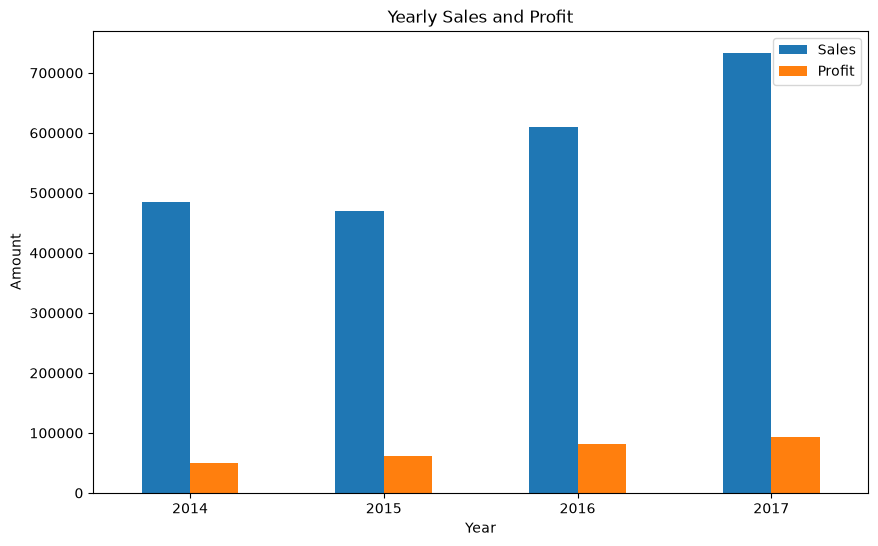

In [258]:
import matplotlib.pyplot as plt

yearly_summary[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Yearly Sales and Profit")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

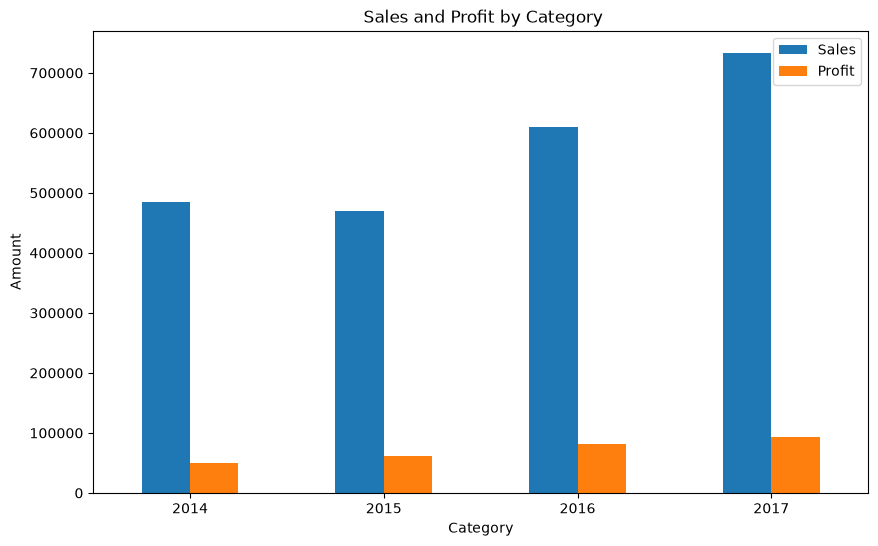

In [259]:
import matplotlib.pyplot as plt
yearly_summary[["Sales","Profit"]].plot(kind = "bar", figsize = (10,6))
plt.title(" Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()


In [260]:
category_summary

,Sales,Profit,Profit Margin %
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


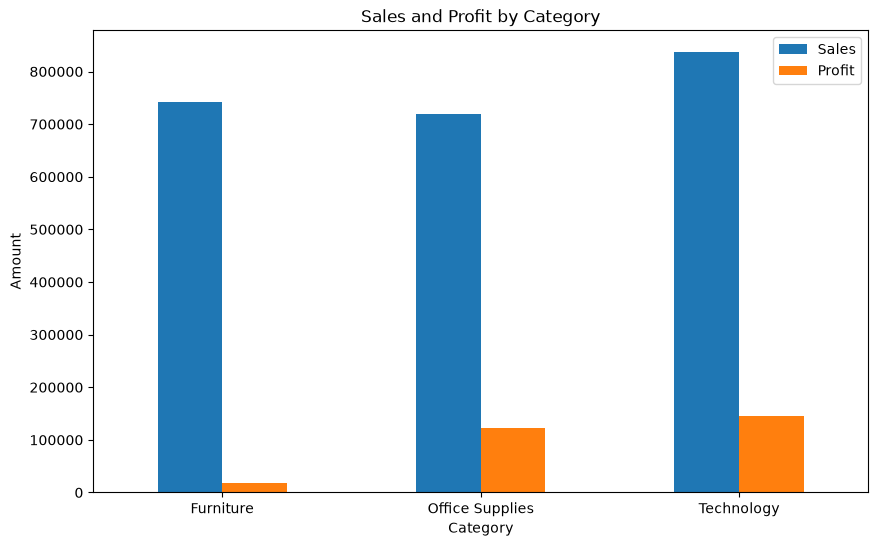

In [261]:
category_summary[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

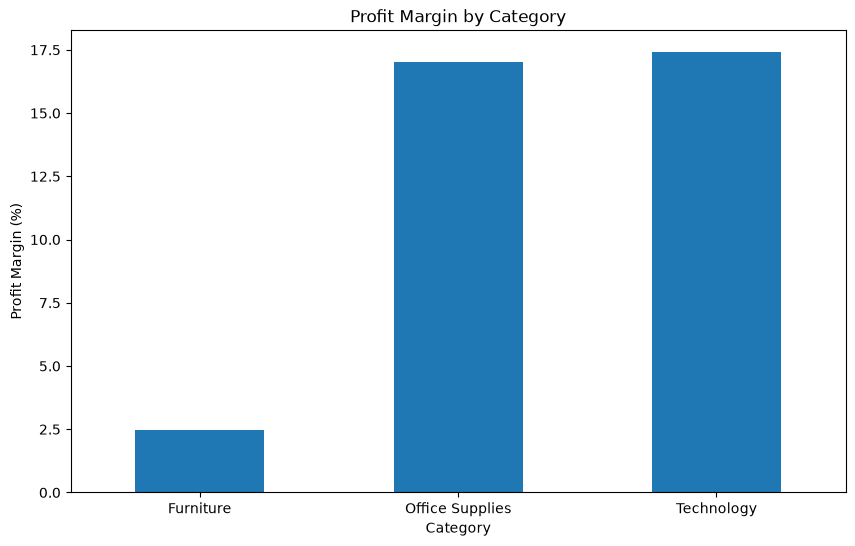

In [262]:
category_summary["Profit Margin % "].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

In [263]:
category_summary.columns

Index(['Sales', 'Profit', 'Profit Margin % '], dtype='str')

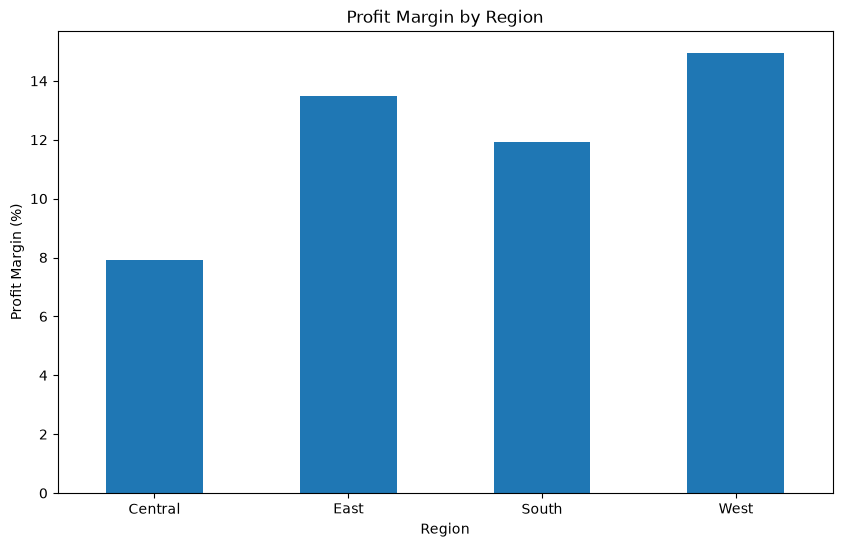

In [264]:
region_summary["Profit Margin %"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

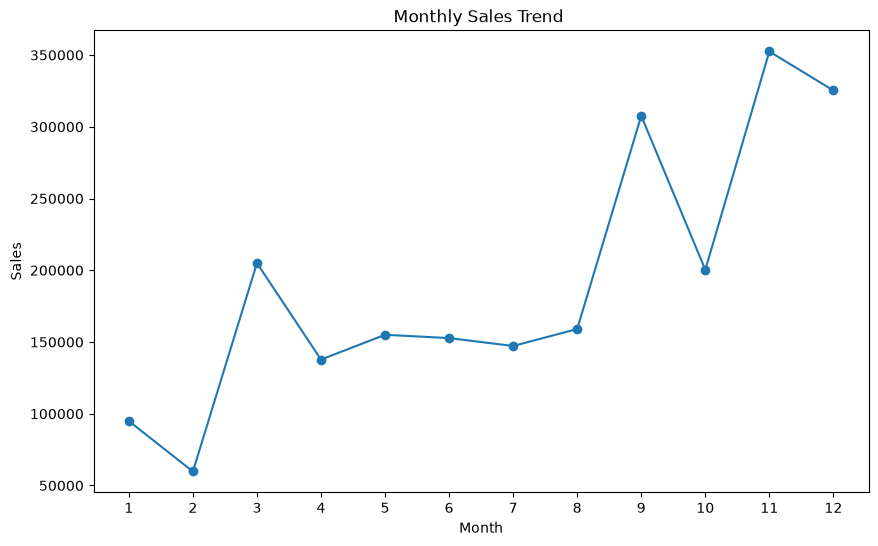

In [265]:
monthly_sales.plot(kind ="line",marker = "o",figsize = (10,6))
plt.title("Monthly Sales Trend ")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1,13))
plt.show()

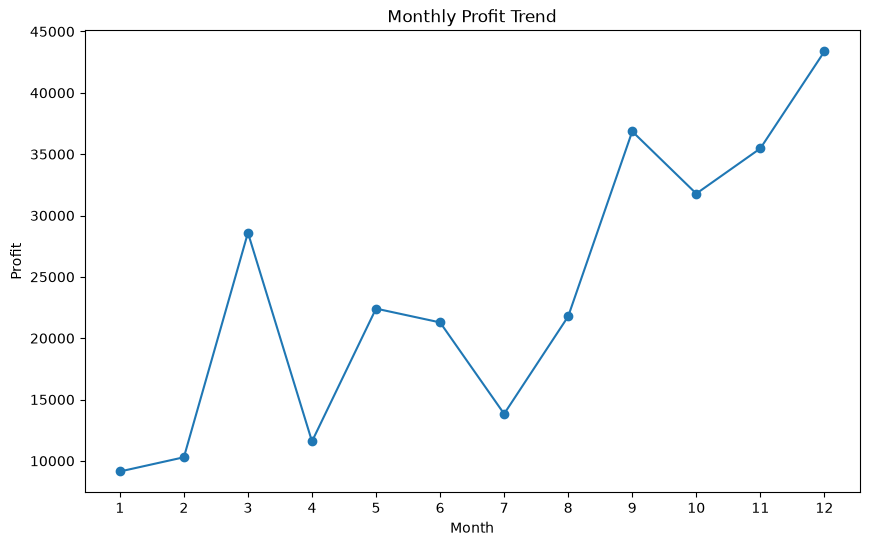

In [266]:
monthly_profit.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(range(1, 13))
plt.show()

In [267]:
product_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [268]:
product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

product_profit.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

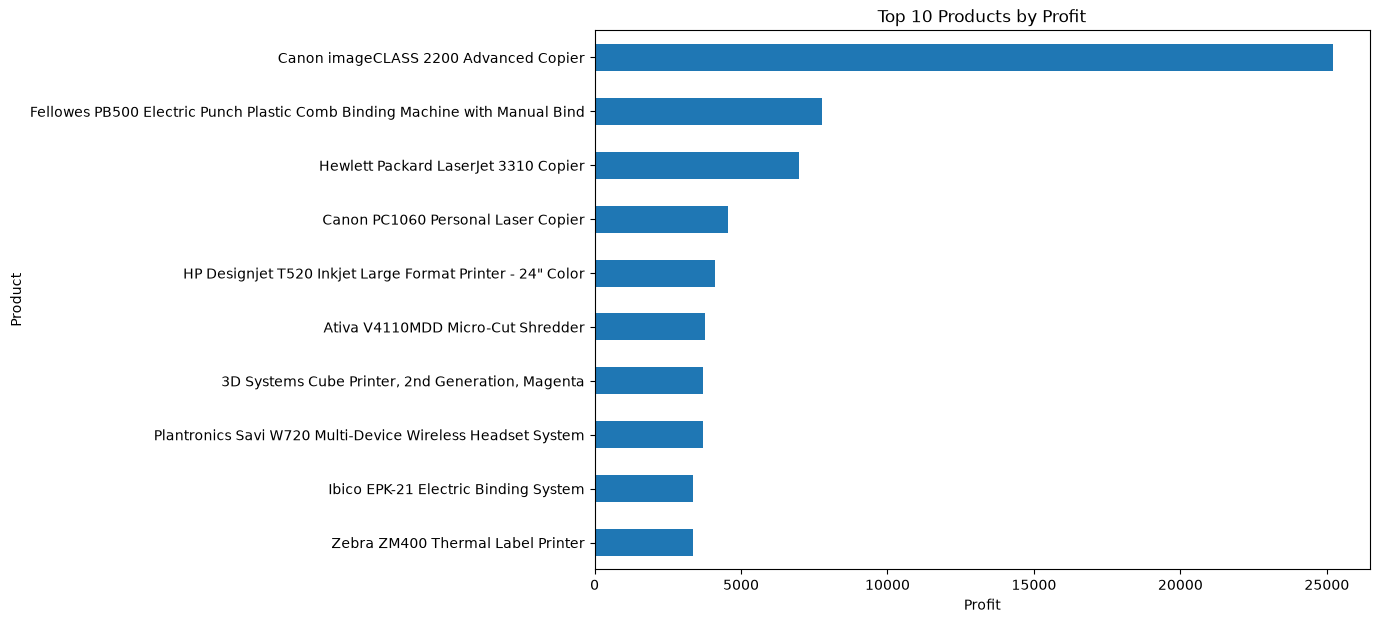

In [269]:
product_profit.head(10).sort_values().plot(kind="barh",figsize=(10,7))
plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.show()

In [270]:
product_losses = (
    product_profit
    .head(10)
    .sort_values()
)

product_losses

Product Name
Zebra ZM400 Thermal Label Printer                                               3343.5360
Ibico EPK-21 Electric Binding System                                            3345.2823
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Canon PC1060 Personal Laser Copier                                              4570.9347
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Name: Profit, dtype: float64

In [271]:
product_losses = (
    product_profit
    .tail(10)
    .sort_values()
)

product_losses

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

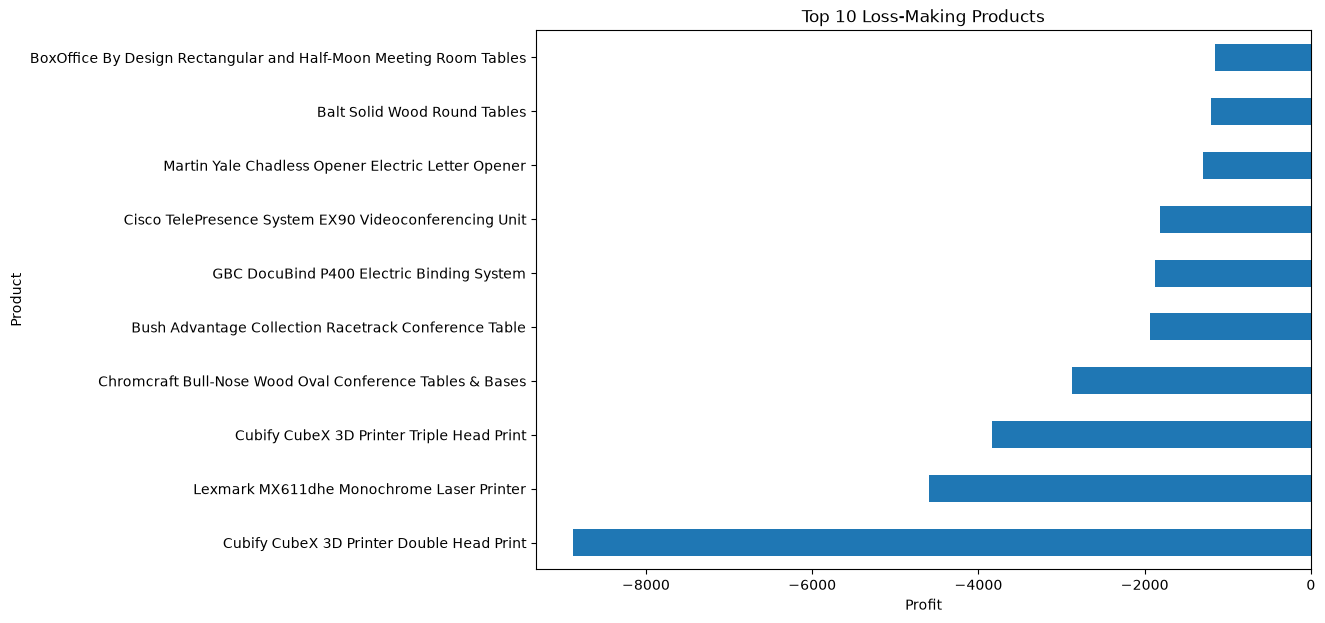

In [272]:
product_losses.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.show()

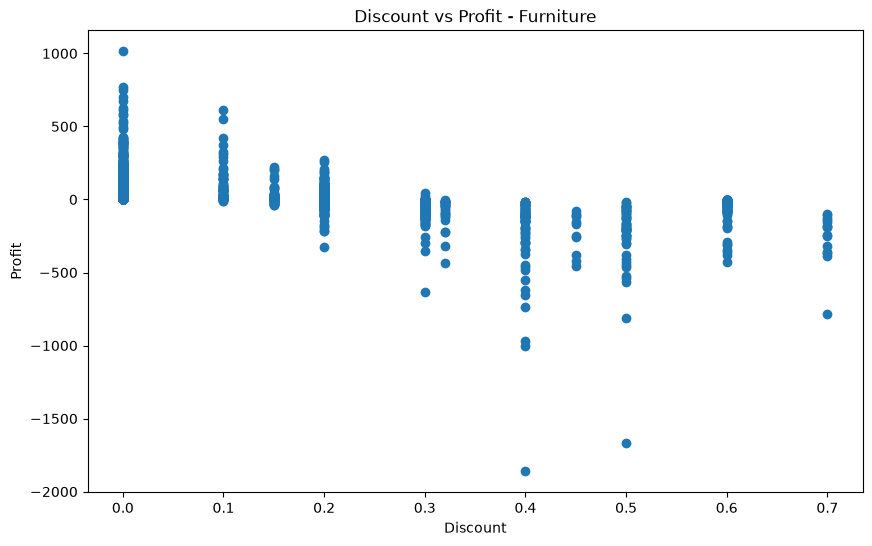

In [273]:
plt.figure(figsize=(10,6))
plt.scatter(furniture_data["Discount"], furniture_data["Profit"])
plt.title("Discount vs Profit - Furniture")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


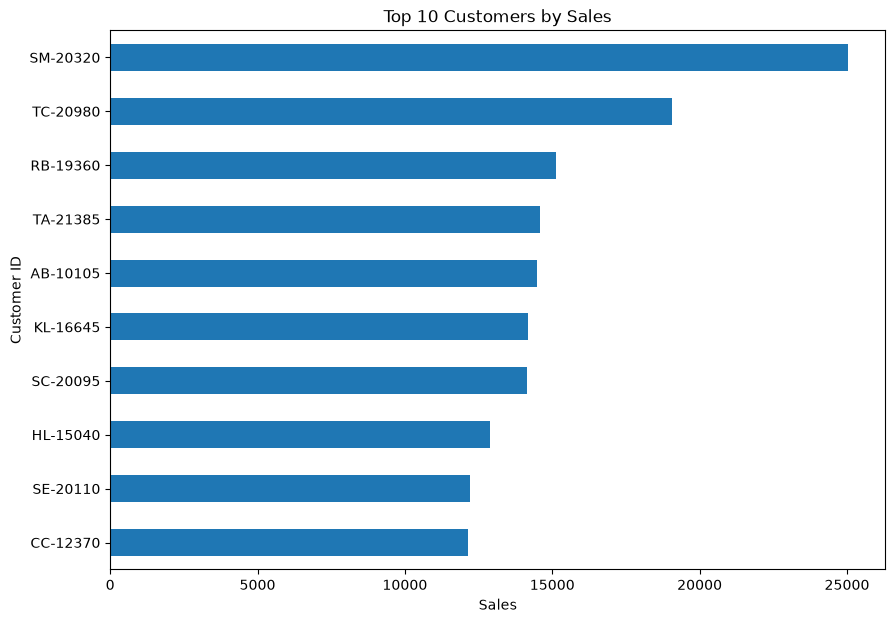

In [274]:
customer_sales.head(10).sort_values().plot(kind="barh",figsize=(10,7))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer ID")
plt.show()

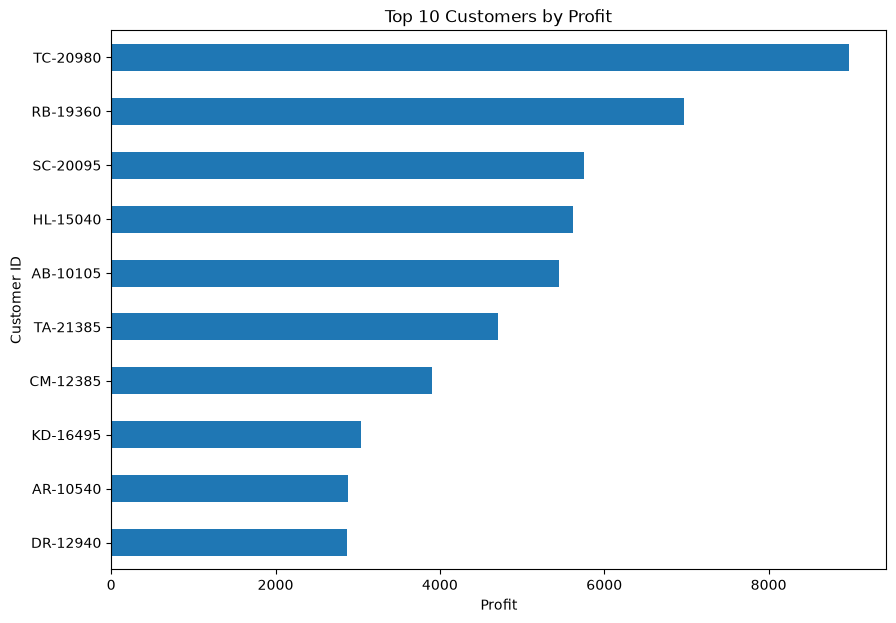

In [275]:
customer_summary["Profit"].sort_values(ascending=False).head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")
plt.ylabel("Customer ID")
plt.show()

In [276]:
loss_customer_profit = (
    customer_summary[customer_summary["Profit"] < 0]["Profit"]
    .sort_values()
    .head(10)
)

loss_customer_profit

Customer ID
CS-12505   -6626.3895
GT-14635   -4108.6589
LF-17185   -3583.9770
SR-20425   -3333.9144
HG-14965   -2797.9635
NC-18415   -2204.8072
SB-20290   -2082.7451
SM-20320   -1980.7393
CP-12340   -1850.3029
NF-18385   -1695.9714
Name: Profit, dtype: float64

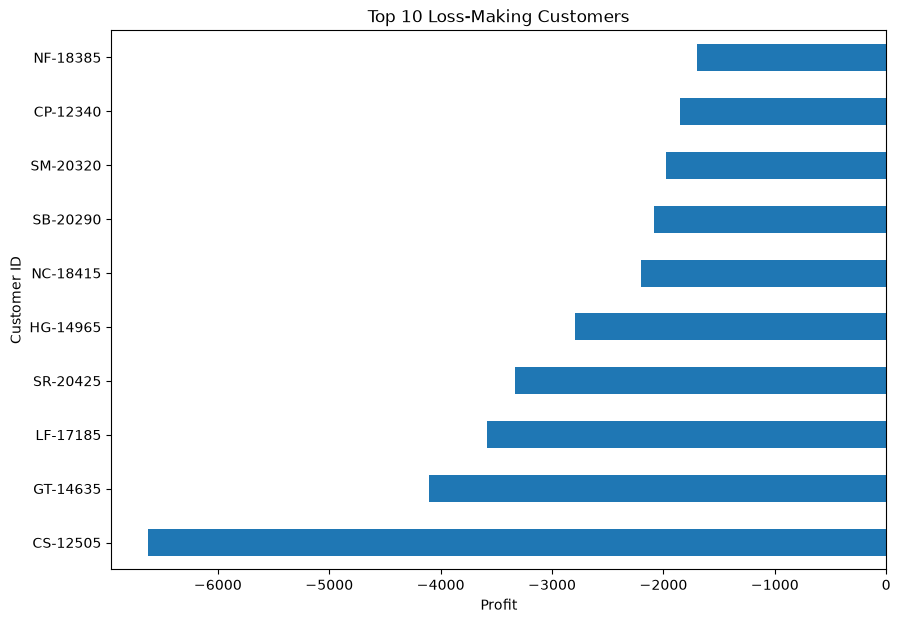

In [277]:
loss_customer_profit.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 10 Loss-Making Customers")
plt.xlabel("Profit")
plt.ylabel("Customer ID")
plt.show()

In [278]:
df.to_csv("../data/superstore_cleaned.csv", index=False)

In [279]:
import os

os.listdir("../data")

['Sample - Superstore.csv',
 'Sample - Superstore.csv.zip',
 'superstore.db',
 'superstore_cleaned.csv']

In [280]:
import sqlite3
connection = sqlite3.connect("../data/superstore.db")
df.to_sql("superstore",connection,if_exists="replace",index=False)
print("SQL database created succesfully")


SQL database created succesfully


In [281]:
cursor = connection.cursor()
cursor.execute(""" SELECT name FROM sqlite_master WHERE type = 'table'; """)
print(cursor.fetchall())


[('customers',), ('superstore',)]


In [282]:
cursor.execute(""" SELECT COUNT(*) FROM superstore ; """)
print(cursor.fetchall())

[(9994,)]


In [283]:
cursor.execute(""" SELECT * FROM superstore LIMIT 5; """)
print(cursor.fetchall())

[(1, 'CA-2016-152156', '2016-11-08 00:00:00', '2016-11-11 00:00:00', 'Second Class', 'CG-12520', 'Claire Gute', 'Consumer', 'United States', 'Henderson', 'Kentucky', 42420, 'South', 'FUR-BO-10001798', 'Furniture', 'Bookcases', 'Bush Somerset Collection Bookcase', 261.96, 2, 0.0, 41.9136, '2016-11-11 00:00:00', 2016, 11, 3), (2, 'CA-2016-152156', '2016-11-08 00:00:00', '2016-11-11 00:00:00', 'Second Class', 'CG-12520', 'Claire Gute', 'Consumer', 'United States', 'Henderson', 'Kentucky', 42420, 'South', 'FUR-CH-10000454', 'Furniture', 'Chairs', 'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back', 731.94, 3, 0.0, 219.582, '2016-11-11 00:00:00', 2016, 11, 3), (3, 'CA-2016-138688', '2016-06-12 00:00:00', '2016-06-16 00:00:00', 'Second Class', 'DV-13045', 'Darrin Van Huff', 'Corporate', 'United States', 'Los Angeles', 'California', 90036, 'West', 'OFF-LA-10000240', 'Office Supplies', 'Labels', 'Self-Adhesive Address Labels for Typewriters by Universal', 14.62, 2, 0.0, 6.8714, '2016

In [284]:
cursor.execute("""
    SELECT SUM(Sales)
    FROM superstore;
""")

print(cursor.fetchall())

[(2297200.8603,)]


In [285]:
cursor.execute("""
    SELECT SUM(Profit)
    FROM superstore;
""")

print(cursor.fetchall())

[(286397.0217,)]


In [286]:
cursor.execute("""
    SELECT
        Category,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    GROUP BY Category;
""")

print(cursor.fetchall())

[('Furniture', 741999.7953, 18451.2728), ('Office Supplies', 719047.032, 122490.8008), ('Technology', 836154.033, 145454.9481)]


In [287]:
cursor.execute("""
    SELECT
        Category,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    GROUP BY Category
    ORDER BY Total_Sales DESC;
""")

print(cursor.fetchall())

[('Technology', 836154.033, 145454.9481), ('Furniture', 741999.7953, 18451.2728), ('Office Supplies', 719047.032, 122490.8008)]


In [288]:
cursor.execute(""" SELECT category, SUM(Sales) AS Total_Sales,SUM(Profit) AS Total_Profit,SUM(Profit)/SUM(Sales) * 100 AS Profit_Margin
FROM superstore
GROUP BY Category
ORDER BY Profit_Margin DESC;
""")
print(cursor.fetchall())

[('Technology', 836154.033, 145454.9481, 17.395712076891936), ('Office Supplies', 719047.032, 122490.8008, 17.035158390028652), ('Furniture', 741999.7953, 18451.2728, 2.4866951334588867)]


In [289]:
cursor.execute("""
    SELECT SUM(Sales)
    FROM superstore
    WHERE Category = 'Furniture';
""")

print(cursor.fetchall())

[(741999.7953,)]


In [290]:
cursor.execute("""
    SELECT COUNT(*)
    FROM superstore
    WHERE Category = 'Furniture';
""")

print(cursor.fetchall())

[(2121,)]


In [291]:
cursor.execute("""
    SELECT
        "Sub-Category",
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    WHERE Category = 'Furniture'
    GROUP BY "Sub-Category"
    ORDER BY Total_Profit ASC;
""")

print(cursor.fetchall())

[('Tables', 206965.532, -17725.4811), ('Bookcases', 114879.9963, -3472.556), ('Furnishings', 91705.164, 13059.1436), ('Chairs', 328449.103, 26590.1663)]


In [292]:
cursor.execute(""" SELECT "Sub_Category",SUM(Sales) AS Total_Sales,SUM(Profit) AS Total_Profit 
FROM superstore 
WHERE Category = "Furniture"
GROUP BY "Sub_Category"
HAVING SUM(Profit) < 0
ORDER BY Total_Profit ASC;
""")

print(cursor.fetchall())

[]


In [293]:
print("SQL test is running")

SQL test is running


In [294]:
cursor.execute("""
    SELECT SUM(Profit)
    FROM superstore
    WHERE Category = 'Furniture';
""")

result = cursor.fetchall()
print(result)

[(18451.2728,)]


In [295]:
cursor.execute("""
    SELECT
        "Sub-Category",
        SUM(Profit)
    FROM superstore
    WHERE Category = 'Furniture'
    GROUP BY "Sub-Category";
""")

result = cursor.fetchall()
print(result)

[('Bookcases', -3472.556), ('Chairs', 26590.1663), ('Furnishings', 13059.1436), ('Tables', -17725.4811)]


In [296]:
cursor.execute("""
    SELECT
        "Sub-Category",
        SUM(Profit)
    FROM superstore
    WHERE Category = 'Furniture'
    GROUP BY "Sub-Category"
    HAVING SUM(Profit) < 0;
""")

result = cursor.fetchall()
print(result)

[('Bookcases', -3472.556), ('Tables', -17725.4811)]


In [297]:
cursor.execute(""" SELECT "Product_Name",Profit,
CASE 
    WHEN Profit > 0 THEN 'Profitable'
    ELSE 'Loss'
    END AS 'Product_Status'
FROM superstore
LIMIT 5;
""")

print(cursor.fetchall())

[('Product_Name', 41.9136, 'Profitable'), ('Product_Name', 219.582, 'Profitable'), ('Product_Name', 6.8714, 'Profitable'), ('Product_Name', -383.031, 'Loss'), ('Product_Name', 2.5164, 'Profitable')]


In [298]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Ship Date]', 'Year', 'Month', 'Shipping Days']


In [299]:
cursor.execute("""
    SELECT "Product Name"
    FROM superstore
    LIMIT 5;
""")

result = cursor.fetchall()
print(result)

[('Bush Somerset Collection Bookcase',), ('Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back',), ('Self-Adhesive Address Labels for Typewriters by Universal',), ('Bretford CR4500 Series Slim Rectangular Table',), ("Eldon Fold 'N Roll Cart System",)]


In [300]:
cursor.execute("""
    SELECT
        "Product Name",
        Profit,
        CASE
            WHEN Profit > 0 THEN 'Profitable'
            ELSE 'Loss'
        END AS Profit_Status
    FROM superstore
    LIMIT 5;
""")

result = cursor.fetchall()
print(result)

[('Bush Somerset Collection Bookcase', 41.9136, 'Profitable'), ('Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back', 219.582, 'Profitable'), ('Self-Adhesive Address Labels for Typewriters by Universal', 6.8714, 'Profitable'), ('Bretford CR4500 Series Slim Rectangular Table', -383.031, 'Loss'), ("Eldon Fold 'N Roll Cart System", 2.5164, 'Profitable')]


In [301]:
cursor.execute("""
    SELECT
        CASE
            WHEN Profit > 0 THEN 'Profitable'
            ELSE 'Loss'
        END AS Profit_Status,
        COUNT(*) AS Transaction_Count
    FROM superstore
    GROUP BY Profit_Status;
""")

result = cursor.fetchall()
print(result)

[('Loss', 1936), ('Profitable', 8058)]


In [302]:
cursor.execute("""
    SELECT
        Category,
        CASE
            WHEN Profit > 0 THEN 'Profitable'
            ELSE 'Loss'
        END AS Profit_Status,
        COUNT(*) AS Transaction_Count
    FROM superstore
    GROUP BY Category, Profit_Status
    ORDER BY Category, Profit_Status;
""")

result = cursor.fetchall()
print(result)

[('Furniture', 'Loss', 747), ('Furniture', 'Profitable', 1374), ('Office Supplies', 'Loss', 915), ('Office Supplies', 'Profitable', 5111), ('Technology', 'Loss', 274), ('Technology', 'Profitable', 1573)]


In [303]:
cursor.execute("""
    SELECT COUNT(DISTINCT "Customer ID")
    FROM superstore;
""")

result = cursor.fetchall()
print(result)


[(793,)]


In [304]:
cursor.execute("""
    SELECT COUNT(DISTINCT "Order ID")
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[(5009,)]


In [305]:
cursor.execute("""
    SELECT
        COUNT(DISTINCT "Order ID") * 1.0
        / COUNT(DISTINCT "Customer ID") AS Orders_Per_Customer
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[(6.316519546027743,)]

In [306]:
cursor.execute("""
    SELECT
        SUM(Sales) * 1.0
        / COUNT(DISTINCT "Order ID") AS Average_Order_Value
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[(458.6146656618087,)]


In [307]:
cursor.execute("""
    SELECT
        Region,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC;
""")

result = cursor.fetchall()
print(result)

[('West', 725457.8245, 108418.4489), ('East', 678781.24, 91522.78), ('Central', 501239.8908, 39706.3625), ('South', 391721.905, 46749.4303)]


In [308]:
cursor.execute("""
    SELECT
        Region,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit,
        SUM(Profit) * 100.0 / SUM(Sales) AS Profit_Margin
    FROM superstore
    GROUP BY Region
    ORDER BY Profit_Margin DESC;
""")

result = cursor.fetchall()
print(result)

[('West', 725457.8245, 108418.4489, 14.944831420727203), ('East', 678781.24, 91522.78, 13.483398568882075), ('South', 391721.905, 46749.4303, 11.93434160900448), ('Central', 501239.8908, 39706.3625, 7.921628591177565)]


In [309]:
cursor.execute("""
    SELECT
        "Sub-Category",
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    WHERE Region = 'Central'
    GROUP BY "Sub-Category"
    HAVING SUM(Profit) < 0
    ORDER BY Total_Profit ASC;
""")

result = cursor.fetchall()
print(result)

[('Furnishings', 15254.37, -3906.2168), ('Tables', 39154.971, -3559.6504), ('Appliances', 23582.033, -2638.6175), ('Bookcases', 24157.1768, -1997.9043), ('Machines', 26797.384000000002, -1486.0665999999999), ('Binders', 56923.282, -1043.636900000001), ('Supplies', 9467.372000000001, -661.8881)]


In [310]:
cursor.execute("""
    SELECT
        "Product Name",
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    GROUP BY "Product Name"
    HAVING SUM(Profit) < 0
    ORDER BY Total_Profit ASC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Cubify CubeX 3D Printer Double Head Print', 11099.963, -8879.9704), ('Lexmark MX611dhe Monochrome Laser Printer', 16829.901, -4589.973), ('Cubify CubeX 3D Printer Triple Head Print', 7999.98, -3839.9904), ('Chromcraft Bull-Nose Wood Oval Conference Tables & Bases', 9917.640000000001, -2876.1156), ('Bush Advantage Collection Racetrack Conference Table', 9544.725, -1934.3976), ('GBC DocuBind P400 Electric Binding System', 17965.068, -1878.1662000000003), ('Cisco TelePresence System EX90 Videoconferencing Unit', 22638.48, -1811.0784), ('Martin Yale Chadless Opener Electric Letter Opener', 16656.2, -1299.1836), ('Balt Solid Wood Round Tables', 6518.754, -1201.0581), ('BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables', 1706.25, -1148.4375)]


In [311]:
cursor.execute("""
    SELECT
        "Order ID",
        "Order Date",
        "Customer Name",
        Region,
        Quantity,
        Sales,
        Discount,
        Profit
    FROM superstore
    WHERE "Product Name" = 'Cubify CubeX 3D Printer Double Head Print'
    ORDER BY Profit ASC;
""")

result = cursor.fetchall()
print(result)

[('CA-2016-108196', '2016-11-25 00:00:00', 'Cindy Stewart', 'East', 5, 4499.985, 0.7, -6599.978), ('CA-2015-147830', '2015-12-15 00:00:00', 'Natalie Fritzler', 'East', 2, 1799.994, 0.7, -2639.9912), ('CA-2017-149881', '2017-04-01 00:00:00', 'Nick Crebassa', 'West', 2, 4799.984, 0.2, 359.9988)]


In [312]:
cursor.execute("""
    SELECT
        MAX(Profit) AS Highest_Profit,
        MIN(Profit) AS Lowest_Profit
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[(8399.976, -6599.978)]


In [313]:
cursor.execute("""
    SELECT
        "Order ID",
        "Product Name",
        "Customer Name",
        Region,
        Sales,
        Discount,
        Profit
    FROM superstore
    ORDER BY Profit ASC
    LIMIT 1;
""")

result = cursor.fetchall()
print(result)

[('CA-2016-108196', 'Cubify CubeX 3D Printer Double Head Print', 'Cindy Stewart', 'East', 4499.985, 0.7, -6599.978)]


In [314]:
cursor.execute("""
    SELECT
        Region,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit,
        ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin
    FROM superstore
    GROUP BY Region
    ORDER BY Profit_Margin DESC;
""")

result = cursor.fetchall()
print(result)

[('West', 725457.82, 108418.45, 14.94), ('East', 678781.24, 91522.78, 13.48), ('South', 391721.91, 46749.43, 11.93), ('Central', 501239.89, 39706.36, 7.92)]


In [315]:
cursor.execute("""
    SELECT
        "Product Name",
        Category,
        "Sub-Category",
        Sales,
        Profit
    FROM superstore
    WHERE "Product Name" LIKE '%Table%'
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Bretford CR4500 Series Slim Rectangular Table', 'Furniture', 'Tables', 957.5775, -383.031), ('Chromcraft Rectangular Conference Tables', 'Furniture', 'Tables', 1706.184, 85.3092), ('Bretford CR4500 Series Slim Rectangular Table', 'Furniture', 'Tables', 1044.63, 240.2649), ('Advantus 10-Drawer Portable Organizer, Chrome Metal Frame, Smoke Drawers', 'Office Supplies', 'Storage', 95.616, 9.5616), ('Eldon Portable Mobile Manager', 'Office Supplies', 'Storage', 158.368, 13.8572), ('Hon Racetrack Conference Tables', 'Furniture', 'Tables', 787.53, 165.3813), ('Bevis 44 x 96 Conference Tables', 'Furniture', 'Tables', 617.7, -407.682), ('Anker Astro 15000mAh USB Portable Charger', 'Technology', 'Phones', 149.97, 5.9988), ('JBL Micro Wireless Portable Bluetooth Speaker', 'Technology', 'Phones', 143.976, 8.9985), ('BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables', 'Furniture', 'Tables', 218.75, -161.875)]


In [316]:
cursor.execute("""
    SELECT "Product Name"
    FROM superstore
    WHERE "Product Name" LIKE '%Table%'
    LIMIT 10;
""")

table_products = cursor.fetchall()

print(table_products)

[('Bretford CR4500 Series Slim Rectangular Table',), ('Chromcraft Rectangular Conference Tables',), ('Bretford CR4500 Series Slim Rectangular Table',), ('Advantus 10-Drawer Portable Organizer, Chrome Metal Frame, Smoke Drawers',), ('Eldon Portable Mobile Manager',), ('Hon Racetrack Conference Tables',), ('Bevis 44 x 96 Conference Tables',), ('Anker Astro 15000mAh USB Portable Charger',), ('JBL Micro Wireless Portable Bluetooth Speaker',), ('BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables',)]


In [317]:
cursor.execute("""
    SELECT
        Category,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    WHERE Category IN ('Furniture', 'Technology')
    GROUP BY Category;
""")

result = cursor.fetchall()
print(result)

[('Furniture', 741999.7953, 18451.2728), ('Technology', 836154.033, 145454.9481)]


In [318]:
cursor.execute("""
    SELECT
        Category,
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit
    FROM superstore
    WHERE Category NOT IN ('Furniture')
    GROUP BY Category;
""")

result = cursor.fetchall()
print(result)

[('Office Supplies', 719047.032, 122490.8008), ('Technology', 836154.033, 145454.9481)]


In [319]:
cursor.execute("""
    SELECT
        "Order ID",
        "Product Name",
        Sales,
        Profit
    FROM superstore
    WHERE Sales BETWEEN 1000 AND 2000
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('CA-2014-115812', 'Chromcraft Rectangular Conference Tables', 1706.184, 85.3092), ('CA-2015-106320', 'Bretford CR4500 Series Slim Rectangular Table', 1044.63, 240.2649), ('CA-2016-117590', 'GE 30524EE4', 1097.544, 123.4737), ('CA-2016-105816', 'AT&T CL83451 4-Handset Telephone', 1029.95, 298.6855), ('CA-2014-106376', 'Hunt BOSTON Model 1606 High-Volume Electric Pencil Sharpener, Beige', 1113.024, 111.3024), ('CA-2016-114489', 'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back', 1951.84, 585.552), ('CA-2014-139892', 'SAFCO Arco Folding Chair', 1740.06, -24.858), ('CA-2015-146262', 'Cisco 9971 IP Video Phone Charcoal', 1188.0, -950.4), ('CA-2014-131926', "Honeywell Enviracaire Portable HEPA Air Cleaner for 17' x 22' Room", 1503.25, 496.0725), ('US-2015-161991', 'Bose SoundLink Bluetooth Speaker', 1114.4, 376.11)]


In [320]:
cursor.execute("""
    SELECT
        "Order ID",
        "Product Name",
        Sales,
        Profit,
        Discount
    FROM superstore
    WHERE Sales BETWEEN 1000 AND 2000
      AND Profit < 0
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('CA-2014-139892', 'SAFCO Arco Folding Chair', 1740.06, -24.858, 0.3), ('CA-2015-146262', 'Cisco 9971 IP Video Phone Charcoal', 1188.0, -950.4, 0.7), ('US-2017-134481', 'Office Impressions End Table, 20-1/2"H x 24"W x 20"D', 1488.424, -297.6848, 0.3), ('CA-2017-117457', 'Bevis Round Conference Table Top, X-Base', 1004.024, -112.9527, 0.2), ('CA-2016-109869', 'Bush Advantage Collection Racetrack Conference Table', 1272.63, -814.4832, 0.5), ('CA-2016-113243', 'Bretford \x93Just In Time\x94 Height-Adjustable Multi-Task Work Tables', 1335.68, -217.048, 0.2), ('CA-2016-158099', 'GBC Ibimaster 500 Manual ProClick Binding System', 1141.47, -760.98, 0.7), ('CA-2015-124891', 'Bevis Round Bullnose 29" High Table Top', 1090.782, -290.8752, 0.4), ('CA-2016-130946', 'GBC DocuBind P400 Electric Binding System', 1088.792, -1850.9464, 0.8), ('US-2017-118087', 'Samsung Galaxy Note 2', 1931.958, -386.3916, 0.4)]


In [321]:
cursor.execute("""
    SELECT
        "Order ID",
        "Product Name",
        Sales,
        Profit
    FROM superstore
    WHERE Profit < -500
       OR Sales > 5000
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('US-2015-150630', 'Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish', 3083.43, -1665.0522), ('CA-2014-139892', 'Lexmark MX611dhe Monochrome Laser Printer', 8159.952, -1359.992), ('CA-2015-146262', 'Cisco 9971 IP Video Phone Charcoal', 1188.0, -950.4), ('US-2014-106992', 'Lexmark MX611dhe Monochrome Laser Printer', 3059.982, -509.997), ('CA-2016-109869', 'Bush Advantage Collection Racetrack Conference Table', 1272.63, -814.4832), ('CA-2015-145352', 'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 6354.95, 3177.475), ('US-2017-168116', 'Cubify CubeX 3D Printer Triple Head Print', 7999.98, -3839.9904), ('CA-2016-158099', 'GBC Ibimaster 500 Manual ProClick Binding System', 1141.47, -760.98), ('US-2017-110576', 'Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer', 2065.32, -619.596), ('CA-2016-130946', 'GBC DocuBind P400 Electric Binding System', 1088.792, -1850.9464)]


In [322]:
cursor.execute("""
    SELECT
        COUNT(*)
    FROM superstore
    WHERE "Postal Code" IS NULL;
""")

result = cursor.fetchall()
print(result)

[(0,)]


In [323]:
cursor.execute("""
    SELECT DISTINCT Category
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[('Furniture',), ('Office Supplies',), ('Technology',)]


In [324]:
cursor.execute("""
    SELECT DISTINCT Region
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[('South',), ('West',), ('Central',), ('East',)]


In [325]:
cursor.execute("""
    SELECT
        "Product Name",
        Sales,
        Profit
    FROM superstore
    ORDER BY Profit DESC, Sales DESC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Canon imageCLASS 2200 Advanced Copier', 17499.95, 8399.976), ('Canon imageCLASS 2200 Advanced Copier', 13999.96, 6719.9808), ('Canon imageCLASS 2200 Advanced Copier', 10499.97, 5039.9856), ('GBC Ibimaster 500 Manual ProClick Binding System', 9892.74, 4946.37), ('Ibico EPK-21 Electric Binding System', 9449.95, 4630.4755), ('Canon imageCLASS 2200 Advanced Copier', 11199.968, 3919.9888), ('Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 6354.95, 3177.475), ('HP Designjet T520 Inkjet Large Format Printer - 24" Color', 8749.95, 2799.984), ('Hewlett Packard LaserJet 3310 Copier', 5399.91, 2591.9568), ('GBC DocuBind P400 Electric Binding System', 5443.96, 2504.2216)]


In [326]:
cursor.execute("""
    SELECT
        AVG(Sales) AS Average_Sales,
        AVG(Profit) AS Average_Profit
    FROM superstore;
""")

result = cursor.fetchall()
print(result)

[(229.85800083049827, 28.65689630778467)]


In [327]:
cursor.execute("""
    SELECT
        Category,
        ROUND(AVG(Sales), 2) AS Avg_Sales,
        ROUND(AVG(Profit), 2) AS Avg_Profit
    FROM superstore
    GROUP BY Category
    ORDER BY Avg_Profit DESC;
""")

result = cursor.fetchall()
print(result)

[('Technology', 452.71, 78.75), ('Office Supplies', 119.32, 20.33), ('Furniture', 349.83, 8.7)]


In [328]:
cursor.execute(""" SELECT 
            MIN("Order Date") AS First_Order_Date,
            MAX("Order Date") AS Last_Order_Date
            FROM superstore;
            """)
print(cursor.fetchall())

[('2014-01-03 00:00:00', '2017-12-30 00:00:00')]


In [329]:
cursor.execute("""
                SELECT
                strftime('%Y',"Order Date") AS Year,
                ROUND(SUM(Sales),2) AS Total_Sales
                FROM superstore
                GROUP BY Year
                ORDER BY Year
                """)
print(cursor.fetchall())

[('2014', 484247.5), ('2015', 470532.51), ('2016', 609205.6), ('2017', 733215.26)]


In [330]:
cursor.execute("""
    SELECT
        strftime('%Y', "Order Date") AS Year,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY Year
    ORDER BY Year;
""")

result = cursor.fetchall()
print(result)

[('2014', 484247.5, 49543.97), ('2015', 470532.51, 61618.6), ('2016', 609205.6, 81795.17), ('2017', 733215.26, 93439.27)]


In [331]:
cursor.execute("""
    SELECT
        strftime('%Y', "Order Date") AS Year,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit,
        ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin
    FROM superstore
    GROUP BY Year
    ORDER BY Year;
""")

result = cursor.fetchall()
print(result)

[('2014', 484247.5, 49543.97, 10.23), ('2015', 470532.51, 61618.6, 13.1), ('2016', 609205.6, 81795.17, 13.43), ('2017', 733215.26, 93439.27, 12.74)]


In [332]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Month,
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY Month
    ORDER BY Month;
""")

result = cursor.fetchall()
print(result)

[('2014-05', 155028.81), ('2014-08', 159044.06), ('2015-09', 307649.95), ('2015-10', 200322.98), ('2016-01', 94924.84), ('2016-03', 205005.49), ('2016-06', 152718.68), ('2016-11', 352461.07), ('2016-12', 325293.5), ('2017-02', 59751.25), ('2017-04', 137762.13), ('2017-07', 147238.1)]


In [333]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY Year_Month
    ORDER BY Year_Month;
""")

result = cursor.fetchall()
print(result)

[('2014-01', 14236.9), ('2014-02', 4519.89), ('2014-03', 55691.01), ('2014-04', 28295.35), ('2014-05', 23648.29), ('2014-06', 34595.13), ('2014-07', 33946.39), ('2014-08', 27909.47), ('2014-09', 81777.35), ('2014-10', 31453.39), ('2014-11', 78628.72), ('2014-12', 69545.62), ('2015-01', 18174.08), ('2015-02', 11951.41), ('2015-03', 38726.25), ('2015-04', 34195.21), ('2015-05', 30131.69), ('2015-06', 24797.29), ('2015-07', 28765.33), ('2015-08', 36898.33), ('2015-09', 64595.92), ('2015-10', 31404.92), ('2015-11', 75972.56), ('2015-12', 74919.52), ('2016-01', 18542.49), ('2016-02', 22978.82), ('2016-03', 51715.88), ('2016-04', 38750.04), ('2016-05', 56987.73), ('2016-06', 40344.53), ('2016-07', 39261.96), ('2016-08', 31115.37), ('2016-09', 73410.02), ('2016-10', 59687.75), ('2016-11', 79411.97), ('2016-12', 96999.04), ('2017-01', 43971.37), ('2017-02', 20301.13), ('2017-03', 58872.35), ('2017-04', 36521.54), ('2017-05', 44261.11), ('2017-06', 52981.73), ('2017-07', 45264.42), ('2017-08', 

In [334]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY Year_Month
    ORDER BY Total_Sales DESC
    LIMIT 1;
""")

result = cursor.fetchall()
print(result)

[('2017-11', 118447.82)]


In [335]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY strftime('%Y-%m', "Order Date")
    ORDER BY Total_Sales ASC
    LIMIT 1;
""")

result = cursor.fetchall()
print(result)

[('2014-02', 4519.89)]


In [336]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY strftime('%Y-%m', "Order Date")
    ORDER BY Year_Month;
""")

result = cursor.fetchall()
print(result)

[('2014-01', 2450.19), ('2014-02', 862.31), ('2014-03', 498.73), ('2014-04', 3488.84), ('2014-05', 2738.71), ('2014-06', 4976.52), ('2014-07', -841.48), ('2014-08', 5318.1), ('2014-09', 8328.1), ('2014-10', 3448.26), ('2014-11', 9292.13), ('2014-12', 8983.57), ('2015-01', -3281.01), ('2015-02', 2813.85), ('2015-03', 9732.1), ('2015-04', 4187.5), ('2015-05', 4667.87), ('2015-06', 3335.56), ('2015-07', 3288.65), ('2015-08', 5355.81), ('2015-09', 8209.16), ('2015-10', 2817.37), ('2015-11', 12474.79), ('2015-12', 8016.97), ('2016-01', 2824.82), ('2016-02', 5004.58), ('2016-03', 3611.97), ('2016-04', 2977.81), ('2016-05', 8662.15), ('2016-06', 4750.38), ('2016-07', 4432.88), ('2016-08', 2062.07), ('2016-09', 9328.66), ('2016-10', 16243.14), ('2016-11', 4011.41), ('2016-12', 17885.31), ('2017-01', 7140.44), ('2017-02', 1613.87), ('2017-03', 14751.89), ('2017-04', 933.29), ('2017-05', 6342.58), ('2017-06', 8223.34), ('2017-07', 6952.62), ('2017-08', 9040.96), ('2017-09', 10991.56), ('2017-10'

In [337]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY strftime('%Y-%m', "Order Date")
    ORDER BY Total_Profit DESC
    LIMIT 1;
""")

result = cursor.fetchall()
print(result)

[('2016-12', 17885.31)]


In [338]:
cursor.execute("""
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY strftime('%Y-%m', "Order Date")
    HAVING SUM(Profit) < 0
    ORDER BY Total_Profit ASC;
""")

result = cursor.fetchall()
print(result)

[('2015-01', 18174.08, -3281.01), ('2014-07', 33946.39, -841.48)]


In [339]:
cursor.execute("""
    SELECT
        "Product Name",
        Sales,
        Profit
    FROM superstore
    WHERE Sales > (
        SELECT AVG(Sales)
        FROM superstore
    )
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Bush Somerset Collection Bookcase', 261.96, 41.9136), ('Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back', 731.94, 219.582), ('Bretford CR4500 Series Slim Rectangular Table', 957.5775, -383.031), ('Mitel 5320 IP Phone VoIP phone', 907.152, 90.7152), ('Chromcraft Rectangular Conference Tables', 1706.184, 85.3092), ('Konftel 250 Conference\xa0phone\xa0- Charcoal black', 911.424, 68.3568), ('Fellowes PB200 Plastic Comb Binding Machine', 407.976, 132.5922), ('Stur-D-Stor Shelving, Vertical 5-Shelf: 72"H x 36"W x 18 1/2"D', 665.88, 13.3176), ('Bretford CR4500 Series Slim Rectangular Table', 1044.63, 240.2649), ('Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish', 3083.43, -1665.0522)]


In [340]:
cursor.execute("""
    SELECT
        "Product Name",
        Sales,
        Profit
    FROM superstore
    WHERE Profit < (
        SELECT AVG(Profit)
        FROM superstore
    )
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Self-Adhesive Address Labels for Typewriters by Universal', 14.62, 6.8714), ('Bretford CR4500 Series Slim Rectangular Table', 957.5775, -383.031), ("Eldon Fold 'N Roll Cart System", 22.368, 2.5164), ('Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood', 48.86, 14.1694), ('Newell 322', 7.28, 1.9656), ('DXL Angle-View Binders with Locking Rings by Samsill', 18.504, 5.7825), ('Xerox 1967', 15.552, 5.4432), ('Holmes Replacement Filter for HEPA Air Cleaner, Very Large Room, HEPA Filter', 68.81, -123.858), ('Storex DuraTech Recycled Plastic Frosted Binders', 2.544, -3.816), ('Stur-D-Stor Shelving, Vertical 5-Shelf: 72"H x 36"W x 18 1/2"D', 665.88, 13.3176)]


In [341]:
cursor.execute("""
    SELECT
        "Order ID",
        "Product Name",
        Sales,
        Profit
    FROM superstore
    WHERE Profit = (
        SELECT MAX(Profit)
        FROM superstore
    );
""")

result = cursor.fetchall()
print(result)

[('CA-2016-118689', 'Canon imageCLASS 2200 Advanced Copier', 17499.95, 8399.976)]


In [342]:
cursor.execute("""
    SELECT
        "Order ID",
        "Product Name",
        Sales,
        Profit
    FROM superstore
    WHERE Profit = (
        SELECT MIN(Profit)
        FROM superstore
    );
""")

result = cursor.fetchall()
print(result)

[('CA-2016-108196', 'Cubify CubeX 3D Printer Double Head Print', 4499.985, -6599.978)]


In [343]:
cursor.execute("""
    SELECT
        "Product Name",
        SUM(Sales) AS Total_Sales
    FROM superstore
    GROUP BY "Product Name"
    HAVING SUM(Sales) > (
        SELECT AVG(Product_Sales)
        FROM (
            SELECT SUM(Sales) AS Product_Sales
            FROM superstore
            GROUP BY "Product Name"
        )
    )
    ORDER BY Total_Sales DESC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Canon imageCLASS 2200 Advanced Copier', 61599.824), ('Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 27453.384000000002), ('Cisco TelePresence System EX90 Videoconferencing Unit', 22638.48), ('HON 5400 Series Task Chairs for Big and Tall', 21870.576), ('GBC DocuBind TL300 Electric Binding System', 19823.479), ('GBC Ibimaster 500 Manual ProClick Binding System', 19024.5), ('Hewlett Packard LaserJet 3310 Copier', 18839.686), ('HP Designjet T520 Inkjet Large Format Printer - 24" Color', 18374.895), ('GBC DocuBind P400 Electric Binding System', 17965.068), ('High Speed Automatic Electric Letter Opener', 17030.311999999998)]


In [344]:
cursor.execute("""
    SELECT AVG(Product_Sales)
    FROM (
        SELECT
            SUM(Sales) AS Product_Sales
        FROM superstore
        GROUP BY "Product Name"
    );
""")

result = cursor.fetchall()
print(result)

[(1241.7301947567566,)]


In [345]:
cursor.execute("""
    SELECT
        "Product Name",
        SUM(Sales) AS Total_Sales
    FROM superstore
    GROUP BY "Product Name"
    HAVING SUM(Sales) > (
        SELECT AVG(Product_Sales)
        FROM (
            SELECT SUM(Sales) AS Product_Sales
            FROM superstore
            GROUP BY "Product Name"
        )
    )
    ORDER BY Total_Sales DESC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Canon imageCLASS 2200 Advanced Copier', 61599.824), ('Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 27453.384000000002), ('Cisco TelePresence System EX90 Videoconferencing Unit', 22638.48), ('HON 5400 Series Task Chairs for Big and Tall', 21870.576), ('GBC DocuBind TL300 Electric Binding System', 19823.479), ('GBC Ibimaster 500 Manual ProClick Binding System', 19024.5), ('Hewlett Packard LaserJet 3310 Copier', 18839.686), ('HP Designjet T520 Inkjet Large Format Printer - 24" Color', 18374.895), ('GBC DocuBind P400 Electric Binding System', 17965.068), ('High Speed Automatic Electric Letter Opener', 17030.311999999998)]


In [346]:
cursor.execute("""
    CREATE TABLE customers AS
    SELECT DISTINCT
        "Customer ID",
        "Customer Name",
        Segment,
        City,
        State,
        Region
    FROM superstore;
""")

connection.commit()

print("Customers table created!")

OperationalError: table customers already exists

In [ ]:
cursor.execute("""
    SELECT *
    FROM customers
    LIMIT 5;
""")

result = cursor.fetchall()
print(result)

[('CG-12520', 'Claire Gute', 'Consumer', 'Henderson', 'Kentucky', 'South'), ('DV-13045', 'Darrin Van Huff', 'Corporate', 'Los Angeles', 'California', 'West'), ('SO-20335', "Sean O'Donnell", 'Consumer', 'Fort Lauderdale', 'Florida', 'South'), ('BH-11710', 'Brosina Hoffman', 'Consumer', 'Los Angeles', 'California', 'West'), ('AA-10480', 'Andrew Allen', 'Consumer', 'Concord', 'North Carolina', 'South')]


In [ ]:
cursor.execute("""
    SELECT
        superstore."Order ID",
        superstore."Customer ID",
        customers."Customer Name",
        superstore.Sales
    FROM superstore
    JOIN customers
        ON superstore."Customer ID" = customers."Customer ID"
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('CA-2016-152156', 'CG-12520', 'Claire Gute', 261.96), ('CA-2016-152156', 'CG-12520', 'Claire Gute', 261.96), ('CA-2016-152156', 'CG-12520', 'Claire Gute', 261.96), ('CA-2016-152156', 'CG-12520', 'Claire Gute', 731.94), ('CA-2016-152156', 'CG-12520', 'Claire Gute', 731.94), ('CA-2016-152156', 'CG-12520', 'Claire Gute', 731.94), ('CA-2016-138688', 'DV-13045', 'Darrin Van Huff', 14.62), ('CA-2016-138688', 'DV-13045', 'Darrin Van Huff', 14.62), ('CA-2016-138688', 'DV-13045', 'Darrin Van Huff', 14.62), ('CA-2016-138688', 'DV-13045', 'Darrin Van Huff', 14.62)]


In [ ]:
cursor.execute("""
    SELECT
        "Customer ID",
        COUNT(*) AS Customer_Rows
    FROM customers
    GROUP BY "Customer ID"
    HAVING COUNT(*) > 1
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('AA-10315', 4), ('AA-10375', 9), ('AA-10480', 4), ('AA-10645', 6), ('AB-10015', 3), ('AB-10060', 8), ('AB-10105', 9), ('AB-10150', 5), ('AB-10165', 7), ('AB-10255', 8)]


In [ ]:
cursor.execute("""
    SELECT *
    FROM customers
    WHERE "Customer ID" = 'AA-10315';
""")

result = cursor.fetchall()
print(result)

[('AA-10315', 'Alex Avila', 'Consumer', 'Minneapolis', 'Minnesota', 'Central'), ('AA-10315', 'Alex Avila', 'Consumer', 'San Francisco', 'California', 'West'), ('AA-10315', 'Alex Avila', 'Consumer', 'Round Rock', 'Texas', 'Central'), ('AA-10315', 'Alex Avila', 'Consumer', 'New York City', 'New York', 'East')]


In [ ]:
cursor.execute("DROP TABLE customers;")

In [ ]:
cursor.execute("""
    CREATE TABLE customers AS
    SELECT DISTINCT
        "Customer ID",
        "Customer Name",
        Segment
    FROM superstore;
""")

connection.commit()

print("Clean customers table created!")

Clean customers table created!


In [ ]:
cursor.execute("""
    SELECT
        "Customer ID",
        COUNT(*) AS Customer_Rows
    FROM customers
    GROUP BY "Customer ID"
    HAVING COUNT(*) > 1;
""")

result = cursor.fetchall()
print(result)

[]


In [ ]:
cursor.execute("""
    SELECT
        superstore."Order ID",
        superstore."Customer ID",
        customers."Customer Name",
        customers.Segment,
        superstore.Sales
    FROM superstore
    JOIN customers
        ON superstore."Customer ID" = customers."Customer ID"
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('CA-2016-152156', 'CG-12520', 'Claire Gute', 'Consumer', 261.96), ('CA-2016-152156', 'CG-12520', 'Claire Gute', 'Consumer', 731.94), ('CA-2016-138688', 'DV-13045', 'Darrin Van Huff', 'Corporate', 14.62), ('US-2015-108966', 'SO-20335', "Sean O'Donnell", 'Consumer', 957.5775), ('US-2015-108966', 'SO-20335', "Sean O'Donnell", 'Consumer', 22.368), ('CA-2014-115812', 'BH-11710', 'Brosina Hoffman', 'Consumer', 48.86), ('CA-2014-115812', 'BH-11710', 'Brosina Hoffman', 'Consumer', 7.28), ('CA-2014-115812', 'BH-11710', 'Brosina Hoffman', 'Consumer', 907.152), ('CA-2014-115812', 'BH-11710', 'Brosina Hoffman', 'Consumer', 18.504), ('CA-2014-115812', 'BH-11710', 'Brosina Hoffman', 'Consumer', 114.9)]


In [ ]:
cursor.execute("""
                SELECT
                customers.segment,
                SUM(superstore.sales) AS Total_Sales
           FROM superstore
           JOIN customers ON superstore."Customer ID" = customers."Customer ID"
           GROUP BY customers.segment
           ORDER BY Total_Sales DESC;
             
        """)
print(cursor.fetchall())


[('Consumer', 1161401.345), ('Corporate', 706146.3668), ('Home Office', 429653.1485)]


In [ ]:
cursor.execute("""
    SELECT
        customers."Customer ID",
        customers."Customer Name"
    FROM customers
    LEFT JOIN superstore
        ON customers."Customer ID" = superstore."Customer ID"
    WHERE superstore."Customer ID" IS NULL;
""")

result = cursor.fetchall()
print(result)

[]


In [ ]:
cursor.execute("""
    SELECT
        customers."Customer ID",
        customers."Customer Name",
        COUNT(DISTINCT superstore."Order ID") AS Total_Orders
    FROM customers
    JOIN superstore
        ON customers."Customer ID" = superstore."Customer ID"
    GROUP BY
        customers."Customer ID",
        customers."Customer Name"
    ORDER BY Total_Orders DESC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('EP-13915', 'Emily Phan', 17), ('CK-12205', 'Chloris Kastensmidt', 13), ('EA-14035', 'Erin Ashbrook', 13), ('JE-15745', 'Joel Eaton', 13), ('NS-18640', 'Noel Staavos', 13), ('PG-18820', 'Patrick Gardner', 13), ('SH-19975', 'Sally Hughsby', 13), ('ZC-21910', 'Zuschuss Carroll', 13), ('AH-10690', 'Anna Häberlin', 12), ('BD-11320', 'Bill Donatelli', 12)]


In [ ]:
cursor.execute("""
                WITH Product_Totals AS (
                SELECT "Product Name",
                SUM(Sales) AS Product_Sales
                FROM superstore
                GROUP BY "Product Name")
                SELECT * FROM Product_Totals
                LIMIT 10;
                """)
print(cursor.fetchall()
      )

[('"While you Were Out" Message Book, One Form per Page', 25.228), ('#10 Gummed Flap White Envelopes, 100/Box', 41.3), ('#10 Self-Seal White Envelopes', 108.682), ('#10 White Business Envelopes,4 1/8 x 9 1/2', 488.904), ('#10- 4 1/8" x 9 1/2" Recycled Envelopes', 286.672), ('#10- 4 1/8" x 9 1/2" Security-Tint Envelopes', 146.688), ('#10-4 1/8" x 9 1/2" Premium Diagonal Seam Envelopes', 176.288), ('#6 3/4 Gummed Flap White Envelopes', 71.28), ('1.7 Cubic Foot Compact "Cube" Office Refrigerators', 2706.08), ('1/4 Fold Party Design Invitations & White Envelopes, 24 8-1/2" X 11" Cards, 25 Env./Pack', 49.980000000000004)]


In [ ]:
cursor.execute("""
    WITH ProductTotals AS (
        SELECT
            "Product Name",
            SUM(Sales) AS Product_Sales
        FROM superstore
        GROUP BY "Product Name"
    )
    SELECT AVG(Product_Sales) AS Average_Product_Sales
    FROM ProductTotals;
""")

result = cursor.fetchall()
print(result)

[(1241.7301947567566,)]


In [ ]:
cursor.execute("""
    WITH ProductTotals AS (
        SELECT
            "Product Name",
            SUM(Sales) AS Product_Sales
        FROM superstore
        GROUP BY "Product Name"
    )
    SELECT
        "Product Name",
        Product_Sales
    FROM ProductTotals
    WHERE Product_Sales > (
        SELECT AVG(Product_Sales)
        FROM ProductTotals
    )
    ORDER BY Product_Sales DESC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('Canon imageCLASS 2200 Advanced Copier', 61599.824), ('Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 27453.384000000002), ('Cisco TelePresence System EX90 Videoconferencing Unit', 22638.48), ('HON 5400 Series Task Chairs for Big and Tall', 21870.576), ('GBC DocuBind TL300 Electric Binding System', 19823.479), ('GBC Ibimaster 500 Manual ProClick Binding System', 19024.5), ('Hewlett Packard LaserJet 3310 Copier', 18839.686), ('HP Designjet T520 Inkjet Large Format Printer - 24" Color', 18374.895), ('GBC DocuBind P400 Electric Binding System', 17965.068), ('High Speed Automatic Electric Letter Opener', 17030.311999999998)]


In [ ]:
cursor.execute("""
    SELECT
        "Customer ID",
        "Order ID",
        Sales,
        SUM(Sales) OVER (
            PARTITION BY "Customer ID"
        ) AS Customer_Total_Sales
    FROM superstore
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('AA-10315', 'CA-2017-147039', 362.94, 5563.56), ('AA-10315', 'CA-2017-147039', 11.54, 5563.56), ('AA-10315', 'CA-2015-121391', 26.96, 5563.56), ('AA-10315', 'CA-2014-128055', 673.568, 5563.56), ('AA-10315', 'CA-2014-128055', 52.98, 5563.56), ('AA-10315', 'CA-2016-103982', 3930.072, 5563.56), ('AA-10315', 'CA-2016-103982', 2.304, 5563.56), ('AA-10315', 'CA-2016-103982', 431.976, 5563.56), ('AA-10315', 'CA-2016-103982', 41.72, 5563.56), ('AA-10315', 'CA-2014-138100', 14.94, 5563.56)]


In [ ]:
cursor.execute("""
            SELECT 
            "Customer ID",
            "Order ID",
            Sales,
            SUM(Sales) OVER () AS Total_Sales
            FROM superstore
            LIMIT 10;
            """)
print(cursor.fetchall())

[('CG-12520', 'CA-2016-152156', 261.96, 2297200.8603), ('CG-12520', 'CA-2016-152156', 731.94, 2297200.8603), ('DV-13045', 'CA-2016-138688', 14.62, 2297200.8603), ('SO-20335', 'US-2015-108966', 957.5775, 2297200.8603), ('SO-20335', 'US-2015-108966', 22.368, 2297200.8603), ('BH-11710', 'CA-2014-115812', 48.86, 2297200.8603), ('BH-11710', 'CA-2014-115812', 7.28, 2297200.8603), ('BH-11710', 'CA-2014-115812', 907.152, 2297200.8603), ('BH-11710', 'CA-2014-115812', 18.504, 2297200.8603), ('BH-11710', 'CA-2014-115812', 114.9, 2297200.8603)]


In [ ]:
cursor.execute("""
    SELECT
        "Customer ID",
        "Customer Name",
        Sales,
        ROW_NUMBER() OVER (
            ORDER BY Sales DESC
        ) AS Sales_Rank
    FROM superstore
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('SM-20320', 'Sean Miller', 22638.48, 1), ('TC-20980', 'Tamara Chand', 17499.95, 2), ('RB-19360', 'Raymond Buch', 13999.96, 3), ('TA-21385', 'Tom Ashbrook', 11199.968, 4), ('HL-15040', 'Hunter Lopez', 10499.97, 5), ('AB-10105', 'Adrian Barton', 9892.74, 6), ('SC-20095', 'Sanjit Chand', 9449.95, 7), ('BS-11365', 'Bill Shonely', 9099.93, 8), ('SE-20110', 'Sanjit Engle', 8749.95, 9), ('CC-12370', 'Christopher Conant', 8399.976, 10)]


In [ ]:
cursor.execute("""
             WITH CustomerTotals AS (
             SELECT
             "Customer ID",
             "Customer Name",
             SUM(Sales) AS Total_Sales
             FROM superstore
             GROUP BY
             "Customer ID",
             "Customer Name"
             )
             SELECT 
             "Customer ID",
             "Customer Name",
             Total_Sales,
             ROW_NUMBER() OVER(
             ORDER BY Total_Sales DESC)
             AS Sales_Rank
             FROM CustomerTotals
             LIMIT 10;
             """)
print(cursor.fetchall())

[('SM-20320', 'Sean Miller', 25043.05, 1), ('TC-20980', 'Tamara Chand', 19052.218, 2), ('RB-19360', 'Raymond Buch', 15117.339, 3), ('TA-21385', 'Tom Ashbrook', 14595.62, 4), ('AB-10105', 'Adrian Barton', 14473.571, 5), ('KL-16645', 'Ken Lonsdale', 14175.229, 6), ('SC-20095', 'Sanjit Chand', 14142.334, 7), ('HL-15040', 'Hunter Lopez', 12873.297999999999, 8), ('SE-20110', 'Sanjit Engle', 12209.438, 9), ('CC-12370', 'Christopher Conant', 12129.072, 10)]


In [ ]:
cursor.execute("""
    WITH CustomerTotals AS (
        SELECT
            "Customer ID",
            "Customer Name",
            SUM(Sales) AS Total_Sales
        FROM superstore
        GROUP BY
            "Customer ID",
            "Customer Name"
    )
    SELECT
        "Customer ID",
        "Customer Name",
        Total_Sales,
        DENSE_RANK() OVER (
            ORDER BY Total_Sales DESC
        ) AS Sales_Rank
    FROM CustomerTotals
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('SM-20320', 'Sean Miller', 25043.05, 1), ('TC-20980', 'Tamara Chand', 19052.218, 2), ('RB-19360', 'Raymond Buch', 15117.339, 3), ('TA-21385', 'Tom Ashbrook', 14595.62, 4), ('AB-10105', 'Adrian Barton', 14473.571, 5), ('KL-16645', 'Ken Lonsdale', 14175.229, 6), ('SC-20095', 'Sanjit Chand', 14142.334, 7), ('HL-15040', 'Hunter Lopez', 12873.297999999999, 8), ('SE-20110', 'Sanjit Engle', 12209.438, 9), ('CC-12370', 'Christopher Conant', 12129.072, 10)]


In [ ]:
cursor.execute("""
    WITH Example AS (
        SELECT 'A' AS Customer, 1000 AS Sales
        UNION ALL
        SELECT 'B', 1000
        UNION ALL
        SELECT 'C', 800
    )
    SELECT
        Customer,
        Sales,
        ROW_NUMBER() OVER (ORDER BY Sales DESC) AS Row_Number,
        RANK() OVER (ORDER BY Sales DESC) AS Rank,
        DENSE_RANK() OVER (ORDER BY Sales DESC) AS Dense_Rank
    FROM Example;
""")

result = cursor.fetchall()
print(result)

[('A', 1000, 1, 1, 1), ('B', 1000, 2, 1, 1), ('C', 800, 3, 3, 2)]


In [ ]:
cursor.execute("""
    WITH MonthlySales AS (
        SELECT
            strftime('%Y-%m', "Order Date") AS Month,
            SUM(Sales) AS Monthly_Sales
        FROM superstore
        GROUP BY strftime('%Y-%m', "Order Date")
    )
    SELECT
        Month,
        Monthly_Sales,
        LAG(Monthly_Sales) OVER (
            ORDER BY Month
        ) AS Previous_Month_Sales
    FROM MonthlySales
    ORDER BY Month
    LIMIT 12;
""")

result = cursor.fetchall()
print(result)

[('2014-01', 14236.895, None), ('2014-02', 4519.892, 14236.895), ('2014-03', 55691.009, 4519.892), ('2014-04', 28295.345, 55691.009), ('2014-05', 23648.287, 28295.345), ('2014-06', 34595.1276, 23648.287), ('2014-07', 33946.393, 34595.1276), ('2014-08', 27909.4685, 33946.393), ('2014-09', 81777.3508, 27909.4685), ('2014-10', 31453.393, 81777.3508), ('2014-11', 78628.7167, 31453.393), ('2014-12', 69545.6205, 78628.7167)]


In [ ]:
cursor.execute("""
    WITH MonthlySales AS (
        SELECT
            strftime('%Y-%m', "Order Date") AS Month,
            SUM(Sales) AS Monthly_Sales
        FROM superstore
        GROUP BY strftime('%Y-%m', "Order Date")
    )
    SELECT
        Month,
        Monthly_Sales,
        LAG(Monthly_Sales) OVER (
            ORDER BY Month
        ) AS Previous_Month_Sales,
        Monthly_Sales - LAG(Monthly_Sales) OVER (
            ORDER BY Month
        ) AS MoM_Change
    FROM MonthlySales
    ORDER BY Month
    LIMIT 12;
""")

result = cursor.fetchall()
print(result)

[('2014-01', 14236.895, None, None), ('2014-02', 4519.892, 14236.895, -9717.003), ('2014-03', 55691.009, 4519.892, 51171.117), ('2014-04', 28295.345, 55691.009, -27395.663999999997), ('2014-05', 23648.287, 28295.345, -4647.058000000001), ('2014-06', 34595.1276, 23648.287, 10946.8406), ('2014-07', 33946.393, 34595.1276, -648.7346000000034), ('2014-08', 27909.4685, 33946.393, -6036.924499999997), ('2014-09', 81777.3508, 27909.4685, 53867.8823), ('2014-10', 31453.393, 81777.3508, -50323.957800000004), ('2014-11', 78628.7167, 31453.393, 47175.32370000001), ('2014-12', 69545.6205, 78628.7167, -9083.0962)]


In [ ]:
cursor.execute("""
    WITH MonthlySales AS (
        SELECT
            strftime('%Y-%m', "Order Date") AS Month,
            SUM(Sales) AS Monthly_Sales
        FROM superstore
        GROUP BY strftime('%Y-%m', "Order Date")
    )
    SELECT
        Month,
        Monthly_Sales,
        LAG(Monthly_Sales) OVER (
            ORDER BY Month
        ) AS Previous_Month_Sales,
        Monthly_Sales - LAG(Monthly_Sales) OVER (
            ORDER BY Month
        ) AS MoM_Change,
        (
            (Monthly_Sales - LAG(Monthly_Sales) OVER (
                ORDER BY Month
            ))
            / LAG(Monthly_Sales) OVER (
                ORDER BY Month
            )
        ) * 100 AS MoM_Percentage
    FROM MonthlySales
    ORDER BY Month
    LIMIT 12;
""")

result = cursor.fetchall()
print(result)

[('2014-01', 14236.895, None, None, None), ('2014-02', 4519.892, 14236.895, -9717.003, -68.25226287052058), ('2014-03', 55691.009, 4519.892, 51171.117, 1132.1314093345593), ('2014-04', 28295.345, 55691.009, -27395.663999999997, -49.19225650948432), ('2014-05', 23648.287, 28295.345, -4647.058000000001, -16.423401093006643), ('2014-06', 34595.1276, 23648.287, 10946.8406, 46.290205290556564), ('2014-07', 33946.393, 34595.1276, -648.7346000000034, -1.875219561265626), ('2014-08', 27909.4685, 33946.393, -6036.924499999997, -17.78369943457615), ('2014-09', 81777.3508, 27909.4685, 53867.8823, 193.00934483936877), ('2014-10', 31453.393, 81777.3508, -50323.957800000004, -61.53776969747472), ('2014-11', 78628.7167, 31453.393, 47175.32370000001, 149.98484805756888), ('2014-12', 69545.6205, 78628.7167, -9083.0962, -11.551881527782838)]


In [ ]:
cursor.execute("""
    SELECT
        "Customer ID",
        "Customer Name",
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit,
        (SUM(Profit) / SUM(Sales)) * 100 AS Profit_Margin
    FROM superstore
    GROUP BY
        "Customer ID",
        "Customer Name"
    ORDER BY Total_Sales DESC
    LIMIT 10;
""")

result = cursor.fetchall()
print(result)

[('SM-20320', 'Sean Miller', 25043.05, -1980.7393000000002, -7.90933732113301), ('TC-20980', 'Tamara Chand', 19052.218, 8981.323900000001, 47.140568620409454), ('RB-19360', 'Raymond Buch', 15117.339, 6976.0959, 46.146321783218596), ('TA-21385', 'Tom Ashbrook', 14595.62, 4703.7883, 32.22739630108211), ('AB-10105', 'Adrian Barton', 14473.571, 5444.8054999999995, 37.61895043040864), ('KL-16645', 'Ken Lonsdale', 14175.229, 806.8549999999999, 5.692006809907621), ('SC-20095', 'Sanjit Chand', 14142.334, 5757.411899999999, 40.71047890680561), ('HL-15040', 'Hunter Lopez', 12873.297999999999, 5622.4292, 43.67512660702798), ('SE-20110', 'Sanjit Engle', 12209.438, 2650.6769, 21.71006478758482), ('CC-12370', 'Christopher Conant', 12129.072, 2177.0492999999997, 17.94901786385636)]


In [ ]:
cursor.execute("""
    SELECT
        "Customer ID",
        "Customer Name",
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit,
        (SUM(Profit) / SUM(Sales)) * 100 AS Profit_Margin
    FROM superstore
    GROUP BY
        "Customer ID",
        "Customer Name"
    HAVING
        SUM(Sales) > 10000
        AND SUM(Profit) < 0
    ORDER BY Total_Sales DESC;
""")

result = cursor.fetchall()
print(result)

[('SM-20320', 'Sean Miller', 25043.05, -1980.7393000000002, -7.90933732113301), ('BM-11140', 'Becky Martin', 11789.630000000001, -1659.9581, -14.079815057809277)]
